In [ ]:
# read the data
import matplotlib.pyplot as plt
import numpy as np
#import pandas as pd
import matplotlib
import pandas as pd
import mne 
import os
from mne.preprocessing import ICA
from scipy.stats import pearsonr
import seaborn as sns
import sys
sys.path.append(os.path.abspath('..'))
from utils import identify_bad_channels,remove_epochs_with_bad_mmn_channels, Average_in_trials_in_time_window,remove_or_interpolate_epochs_with_n_bad_chn


mne.set_log_level('WARNING')  # Options: 'DEBUG', 'INFO', 'WARNING', 'ERROR', 'CRITICAL'

In [2]:
subject_info= pd.read_excel(r"E:\ecf-exp2-notif-mmn\data\Processed\Participant_details.xlsx")
subject_info.head()

,participant_id,age,is_controlled_block,gender,profession,b1_deviant,b2_deviant,b3_deviant
0,sd011,30,N,M,PG_acd,PN,BT,NaN
1,sd012,25,N,M,PG_acd,PN,BT,NaN
2,sd013,25,N,M,PG_acd,PN,BT,NaN
3,sd014,28,N,M,PG_acd,PN,BT,NaN
4,sd015,31,N,M,PG_acd,PN,BT,NaN


# Combined Block 1 and 2 results

In [4]:

data_folder = r"D:\Work_data\Notification_evoked_response\Data_at_IITD/bids_data/"
subjects = [sub for sub in os.listdir(data_folder) if (("sub-" in sub) & (os.path.isdir(os.path.join(data_folder,sub))))]
print(subjects)
data_type = "eeg"
 # it is useful to scroll eeg data 
B1_MMN_erp_evoked_dict  = {}
B1_devi_eps_evoked_dict  = {}
B1_sta_eps_evoked_dict  = {}
B2_devi_eps_evoked_dict = {}
B2_sta_eps_evoked_dict = {}
B2_MMN_erp_evoked_dict = {}
CN_devi_eps_evoked_dict = {}
CN_sta_eps_evoked_dict = {}
epoch_per_num = {}
epoch_per_num["subject Dropped"] = []
for sub in subjects:
    path = os.path.join(data_folder,sub,data_type)
    
    for eeg in os.listdir(path):
        print(sub)
        if eeg[-5:] == ".vhdr":
            if   sub   in  ['sub-sd041','sub-sd046','sub-sd058',"sub-sd052"]:
                continue
               
            raw = mne.io.read_raw_brainvision(os.path.join(path,eeg), preload=True)
            print(os.path.join(path,eeg))
            #raw = mne.add_reference_channels(raw, ref_channels=["Cz"])
            raw.set_montage("easycap-M1")
            #raw.plot(scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue",event_color ='black',show_options=True )
            # Now re-reference the data :-n average reference 
            #raw.set_eeg_reference('average')
            raw.set_eeg_reference(ref_channels=['TP9', 'TP10'])
            raw.resample(512) 
            # filter 
            raw.filter(l_freq=0.1,h_freq=30  )
            #ICA 
            ica = ICA(n_components=20, random_state=97,max_iter=500)
            ica.fit(raw)
            print("ICA Completed ...")
            ica.plot_components()
            #removing Eye movement artifacts 
            eog_channels = ['Fp1', 'Fp2',"AF7","AF8",'F7', 'F8']  # Adjust these to match your channel names
            eog_indices, eog_scores = ica.find_bads_eog(raw, ch_name=eog_channels)
            print(eog_indices, eog_scores)
            ica.exclude = eog_indices
            ica.apply(raw)
            #raw.plot(scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue" )
            events,event_dict = mne.events_from_annotations(raw)
            #   print(events,event_dict)
            # Create Epochs without droping the eye blink event
            S14= event_dict['Stimulus/S   14']
            S15 = event_dict['Stimulus/S   15']
            S24 = event_dict['Stimulus/S   24']
            S25 = event_dict['Stimulus/S   25']
            epochs = mne.Epochs(raw, events, event_id=[S14,S15,S24,S25],baseline=(None, 0), tmin=-0.300, tmax=0.700, preload=True,event_repeated='merge')
            # Define your MMN channels

            mmn_channels = [ 'Fz', 'Cz','Pz']  #Example MMN channels, adjust as needed
            try:
                epochs.drop_channels(['GSR', 'PPG'])
                S34 = event_dict['Stimulus/S   34']
                S35 = event_dict['Stimulus/S   35']
                
                CN_epochs = mne.Epochs(raw, events, event_id=[  S34,S35],baseline=(None, 0), tmin=-0.300, tmax=0.700, preload=True,event_repeated='merge')
                CN_epochs.drop_channels(['GSR', 'PPG'])
                #CN_cleaned_epochs = remove_or_interpolate_epochs_with_n_bad_chn(CN_epochs,  bad_chn_threshold = 6, amplitude_threshold=75e-6)
                CN_cleaned_epochs = remove_epochs_with_bad_mmn_channels(CN_epochs, mmn_channels, amplitude_threshold=80e-6)
                CN_devi_eps = CN_cleaned_epochs[str(S35)].average()
                CN_sta_eps = CN_cleaned_epochs[str(S34)].average()
                CN_devi_eps_evoked_dict[sub] = CN_devi_eps
                CN_sta_eps_evoked_dict[sub] = CN_sta_eps
            except:                                  
                print("NO PPG sensor")
                
                pass
            cleaned_epochs = remove_or_interpolate_epochs_with_n_bad_chn(epochs,  bad_chn_threshold = 6, amplitude_threshold=75e-6)
            #cleaned_epochs = remove_epochs_with_n_bad_channels(epochs, bad_chn_thresold = 8, amplitude_threshold=80e-6)
            #cleaned_epochs = remove_epochs_with_bad_mmn_channels(epochs, mmn_channels, amplitude_threshold=80e-6)
            """if len(cleaned_epochs[str(S14),str(S15)]) < 450 or  len(cleaned_epochs[str(S24),str(S25)]) < 450 :
                epoch_per_num["subject Dropped"].append(sub)  
                print("B1 len :",len(cleaned_epochs[str(S14),str(S15)]),"B2 len :",len(cleaned_epochs[str(S24),str(S25)]))
                continue"""

            print(f"Original number of epochs: {len(epochs)}")
            print(f"Number of epochs after removal: {len(cleaned_epochs)}")
            epoch_per_num[sub] = len(cleaned_epochs)    
            try:
                B1_devi_eps = cleaned_epochs[str(S15)].average()
                B1_sta_eps = cleaned_epochs[str(S14)].average()
                B1_MMN_erp = mne.combine_evoked([ B1_devi_eps,B1_sta_eps], weights=[1,-1])
                evokeds = dict(B1_MMN_erp =B1_MMN_erp, B1_devi_eps= B1_devi_eps,B1_sta_eps=B1_sta_eps)  
            
                B1_devi_eps_evoked_dict[sub] = B1_devi_eps
                B1_sta_eps_evoked_dict[sub] = B1_sta_eps
                B1_MMN_erp_evoked_dict[sub] = B1_MMN_erp
                #mne.viz.plot_compare_evokeds(evokeds, picks=picks,title  = str (sub) + " BLock1 avaerage 'F3', 'Fz', 'F4'", combine="mean")

                # Block 2 

                B2_devi_eps = cleaned_epochs[str(S25)].average()
                B2_sta_eps = cleaned_epochs[str(S24)].average()    
                B2_MMN_erp = mne.combine_evoked([ B2_devi_eps,B2_sta_eps], weights=[1,-1])
                evokeds = dict(B2_MMN_erp =B2_MMN_erp, B2_devi_eps= B2_devi_eps,B2_sta_eps=B2_sta_eps)  
            
                B2_devi_eps_evoked_dict[sub] = B2_devi_eps
                B2_sta_eps_evoked_dict[sub] = B2_sta_eps
                B2_MMN_erp_evoked_dict[sub] = B2_MMN_erp
            except:   
                print("ERRor FOr epoching ")    

In [8]:
epoch_per_num

{'subject Dropped': [],
 'sub-sd011': 1411,
 'sub-sd012': 1684,
 'sub-sd013': 1723,
 'sub-sd014': 500,
 'sub-sd015': 1759,
 'sub-sd016': 1792,
 'sub-sd017': 1601,
 'sub-sd018': 1667,
 'sub-sd019': 1080,
 'sub-sd020': 1772,
 'sub-sd021': 1548,
 'sub-sd022': 1766,
 'sub-sd023': 1326,
 'sub-sd024': 1740,
 'sub-sd025': 1753,
 'sub-sd026': 1532,
 'sub-sd027': 1747,
 'sub-sd028': 1739,
 'sub-sd029': 1760,
 'sub-sd030': 1793,
 'sub-sd031': 1765,
 'sub-sd032': 1550,
 'sub-sd033': 1776,
 'sub-sd034': 1690,
 'sub-sd035': 1575,
 'sub-sd036': 1697,
 'sub-sd037': 1772,
 'sub-sd038': 1587,
 'sub-sd039': 1787,
 'sub-sd040': 1532,
 'sub-sd042': 1737,
 'sub-sd043': 520,
 'sub-sd044': 1629,
 'sub-sd045': 1573,
 'sub-sd047': 1502,
 'sub-sd048': 1769,
 'sub-sd049': 1788,
 'sub-sd050': 1653,
 'sub-sd051': 1238,
 'sub-sd053': 1586,
 'sub-sd054': 1083,
 'sub-sd055': 873,
 'sub-sd056': 1603,
 'sub-sd057': 1549,
 'sub-sd059': 1723,
 'sub-sd060': 1787,
 'sub-sd061': 1480,
 'sub-sd062': 1795,
 'sub-sd063': 1720,

In [204]:
print(len(epoch_per_num))

54


In [10]:
#B1_devi_eps_evoked_dict['SD014','SD043','SD051','SD054','SD054','SD']
B1_devi_eps_evoked_list1 = [B1_devi_eps_evoked_dict[sub] for sub in B1_devi_eps_evoked_dict if sub not in ['sub-sd041','sub-sd046','sub-sd058']]
len(B1_devi_eps_evoked_list1) 

53

In [219]:
B1_devi_eps_evoked_list = [B1_devi_eps_evoked_dict[sub] for sub in B1_devi_eps_evoked_dict if sub not in ['sub-sd041','sub-sd046','sub-sd058','sub-sd050','sub-sd034']]

B1_sta_eps_evoked_list = [B1_sta_eps_evoked_dict[sub] for sub in B1_sta_eps_evoked_dict if sub not in ['sub-sd041','sub-sd046','sub-sd058','sub-sd050','sub-sd034']]

B2_devi_eps_evoked_list =  [B2_devi_eps_evoked_dict[sub] for sub in B2_devi_eps_evoked_dict if sub not in ['sub-sd041','sub-sd046','sub-sd058','sub-sd050','sub-sd034']]

B2_sta_eps_evoked_list = [B2_sta_eps_evoked_dict[sub] for sub in B2_sta_eps_evoked_dict if sub not in ['sub-sd041','sub-sd046','sub-sd058','sub-sd050','sub-sd034']]
B2_sta_combined_erp = mne.grand_average(B2_sta_eps_evoked_list )     
Personal_MMN_evokeds_list = [
    mne.combine_evoked([B1_devi_eps_evoked_dict[sub], B2_sta_eps_evoked_dict[sub]], weights=[1, -1]) 
    for sub in B1_devi_eps_evoked_dict
    ]



non_sign_MMN_evokeds_list = [
    mne.combine_evoked([B2_devi_eps_evoked_dict[sub], B1_sta_eps_evoked_dict[sub]], weights=[1, -1])
    for sub in B2_devi_eps_evoked_dict
]


In [ ]:
len(B1_devi_eps_evoked_list)

### Ploting functions

In [ ]:


def plot_erps(evoked_dict, picks, stylesdict, text_labels=None, title='', ylim=(-6.2, 6.2), time_range=(-0.1, 0.7), ylabel='Evoked Responses (µV)', dpi=100,ci=True,axs = None):
    """
    Plot personalized ERP comparisons using MNE's plot_compare_evokeds with consistent formatting.

    Parameters:
    - evoked_dict: dict, keys are condition names, values are lists of evoked objects
    - picks: list of channels (e.g., ['F3', 'Cz', 'F4']), only one pick will be used per plot
    - stylesdict: dict, keys must match evoked_dict keys; values are style dicts (linewidth, linestyle)
    - colors: list of colors for each condition (must match order of evoked_dict)
    - text_labels: list of (y_position, label_text), optional, for manual line legend
    - title: string, title of the plot
    - ylim: dict or tuple, y-axis limits
    - time_range: tuple, time cropping range (e.g., (-0.1, 0.7))
    - ylabel: string, y-axis label
    - dpi: int, resolution of figure

    Returns:
    - fig, axs: matplotlib Figure and Axes objects
    """

    # Crop each evoked list to specified time range
    evokeds_subset = {}
    for cond in evokeds:
        evoked_crop  = [evk.copy().crop(tmin=time_range[0], tmax=time_range[1]) for evk in evokeds[cond]]
        evokeds_subset[cond]  =evoked_crop 
    
    # Plot
    
    if axs is None:
        fig, axs = plt.subplots(figsize=(6, 5), dpi=100)
        return_fig = True
    else:
        return_fig = False
    mne.viz.plot_compare_evokeds(
        evokeds_subset,
        picks=picks,  # Usually 'Cz'
        
        show_sensors=False,
        legend=False,
        styles=stylesdict,
        combine='mean',
        axes=axs,
        ylim=dict(eeg=ylim),
        time_unit='ms',
        truncate_xaxis=False,
        truncate_yaxis=False,
        show=False,
        title=title,ci=ci,
    )

    # Optional manual line labels
    if text_labels:
        for y, txt,col in text_labels:
            axs.text(0.75, y, txt, transform=axs.transAxes, fontsize=18,color=col)

    axs.set_ylabel(ylabel)
    axs.set_xticks(np.arange(0, time_range[1]*1000 + 100, 200))  # Ticks every 0.5 units
    #axs.set_yticks(np.arange(-1, 1.1, 0.2)) # Ticks every 0.2 units
    axs.grid(which='major', linestyle='-')

    # Enable minor ticks and grid
    axs.minorticks_on()
    axs.grid(which='minor', linestyle=':')
    # Set consistent font sizes
    plt.rcParams.update({
        'xtick.labelsize': 18,
        'ytick.labelsize': 18,
        'axes.labelsize': 18,
        'axes.titlesize': 18,
        'legend.fontsize': 18,
    })

    plt.tight_layout()
    
    if return_fig:
        return fig, axs
    
    else:
        return axs


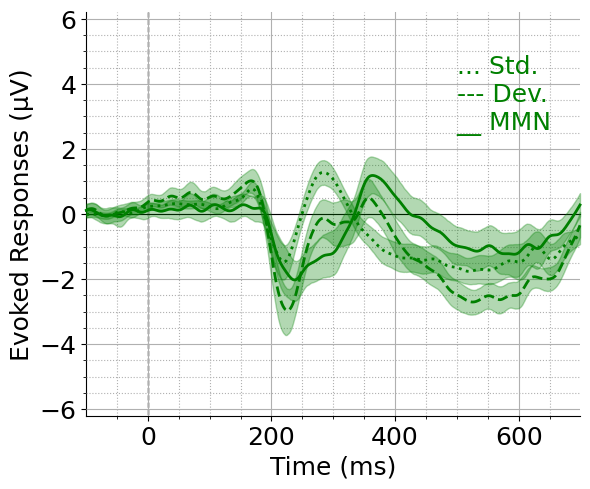

In [320]:
# Define inputs
evokeds = {
           'Non Ps deviant': B2_devi_eps_evoked_list,
           'Non PS std':B1_sta_eps_evoked_list,
           'Non PS MMN': non_sign_MMN_evokeds_list ,
                      }
# Subset the evoked data by selecting the time range




stylesdict ={'Non Ps deviant': {"linewidth": 2,"linestyle":'--','color':'green'},
             'Non PS std' : {"linewidth": 2,"linestyle":'dotted','color':'green'},
             'Non PS MMN' :  {"linewidth": 2,"linestyle":'solid','color':'green'},
             }
colors = ['green', 'green', 'green']
text_labels = [
    (0.85, "... Std.",'green'),
    (0.78, "--- Dev.",'green'),
    (0.71, "__ MMN",'green')
]

# Call the function
fig, axs = plot_erps(evokeds, picks=[ 'Cz'],
                                   stylesdict=stylesdict,
                                   
                                   text_labels=text_labels)
plt.show()

### Non Personal significNCE (deep Tone )  MMN ERP

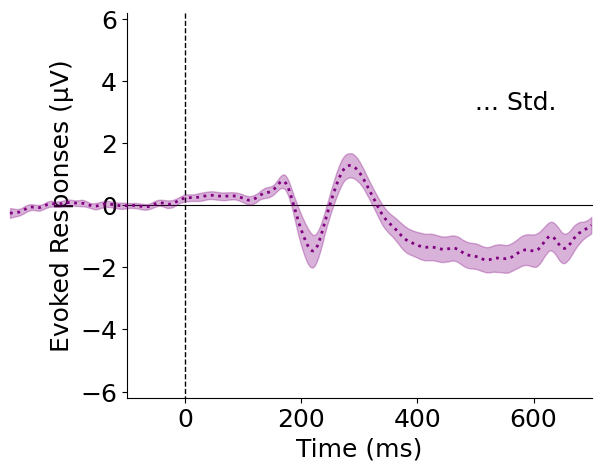

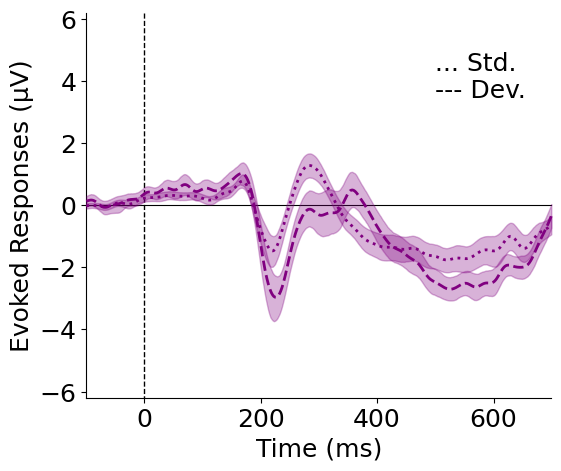

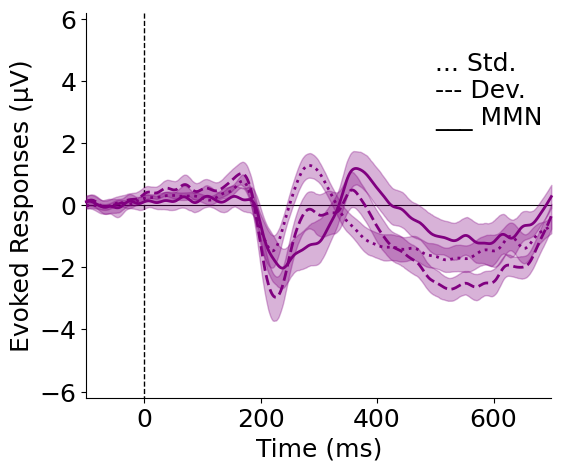

In [ ]:
picks= ['F3', 'Cz', 'F4',]
# Define the start and end time for the window 
start_time = -0.1  # Start of time window in seconds
end_time = 0.6
# End of time window
# ### Personalized siginificant ERP for all the categories
evokeds = {
    'Non PS std':B1_sta_eps_evoked_list,
           
           }

# Subset the evoked data by selecting the time range
"""
  

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = [ evk.copy().crop(tmin=start_time, tmax=end_time) for evk in evokeds]
    evokeds_subset[key] = evoked_crop
"""
evokeds_subset = {}
for cond in evokeds:
    evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
    evokeds_subset[cond]  =evoked_crop 
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)

stylesdict ={
             'Non PS std' : {"linewidth": 2,"linestyle":'dotted'},
             }
mne.viz.plot_compare_evokeds(evokeds, picks=picks[1],colors = ['purple'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',  
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.75,0.750, f"... Std.", transform=axs.transAxes, fontsize=18)
axs.set_ylabel('Evoked Responses (µV)')
axs.set_xlim(-100, 700)
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
           'Non Ps deviant': B2_devi_eps_evoked_list,
           'Non PS std':B1_sta_eps_evoked_list,
                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}
for cond in evokeds:
    evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
    evokeds_subset[cond]  =evoked_crop 



stylesdict ={'Non Ps deviant': {"linewidth": 2,"linestyle":'--'},
             'Non PS std' : {"linewidth": 2,"linestyle":'dotted'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['purple','purple'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.75,0.85, f"... Std.", transform=axs.transAxes, fontsize=18)
axs.text( 0.75,0.78, f"--- Dev.", transform=axs.transAxes, fontsize=18)
axs.set_ylabel('Evoked Responses (µV)')
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
           'Non Ps deviant': B2_devi_eps_evoked_list,
           'Non PS std':B1_sta_eps_evoked_list,
           'Non PS MMN': non_sign_MMN_evokeds_list ,
                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}
for cond in evokeds:
    evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
    evokeds_subset[cond]  =evoked_crop 



stylesdict ={'Non Ps deviant': {"linewidth": 2,"linestyle":'--'},
             'Non PS std' : {"linewidth": 2,"linestyle":'dotted'},
             'Non PS MMN' :  {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['purple','purple','purple'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes=axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title='')
axs.text( 0.75,0.85, f"... Std.", transform=axs.transAxes, fontsize=18)
axs.text( 0.75,0.78, f"--- Dev.", transform=axs.transAxes, fontsize=18)
axs.text( 0.75,0.71, f"___ MMN", transform=axs.transAxes, fontsize=18)
axs.set_ylabel('Evoked Responses (µV)')
plt.rcParams.update({
    'xtick.labelsize': 18,  # X-axis tick labels font size 
    'ytick.labelsize': 18,  # Y-axis tick labels font size
    'axes.labelsize': 18,   # Axis label font size
    'axes.titlesize': 18,   # Title font size 
    'legend.fontsize': 18,   # Legend font size
})
plt.show( )# export it 

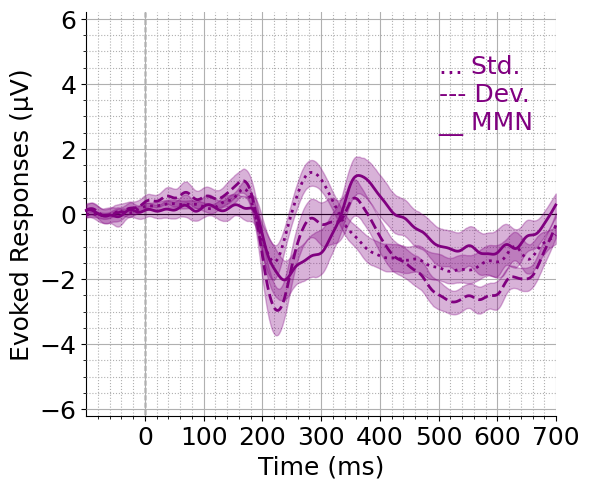

In [ ]:

evokeds = {
           'Non Ps deviant': B2_devi_eps_evoked_list,
           'Non PS std':B1_sta_eps_evoked_list,
           'Non PS MMN': non_sign_MMN_evokeds_list ,
                      }



stylesdict ={'Non Ps deviant': {"linewidth": 2,"linestyle":'--',"color": 'purple'},
             'Non PS std' : {"linewidth": 2,"linestyle":'dotted',"color": 'purple'},
             'Non PS MMN' :  {"linewidth": 2,"linestyle":'solid',"color": 'purple'},
             }
text_labels = [
    (0.85, "... Std.",'purple'),
    (0.78, "--- Dev.",'purple'),
    (0.71, "__ MMN",'purple')
]

# Call the function
fig, axs = plot_erps(evokeds, picks=[ 'Cz'],
                                   stylesdict=stylesdict,
                                   
                                   text_labels=text_labels)
plt.show()

### Personal significNCE (smartphone notification )  MMN ERP

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_3928\1874287216.py:11: RuntimeWarning: tmax is not in time interval. tmax is set to <class 'mne.evoked.EvokedArray'>.tmax (0.699219 s)
  evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_3928\1874287216.py:11: RuntimeWarning: tmax is not in time interval. tmax is set to <class 'mne.evoked.EvokedArray'>.tmax (0.699219 s)
  evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_3928\1874287216.py:11: RuntimeWarning: tmax is not in time interval. tmax is set to <class 'mne.evoked.EvokedArray'>.tmax (0.699219 s)
  evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_3928\1874287216.py:11: RuntimeWarning: tmax is not in time interval. tmax is set to <class 'mne.evoked.EvokedArray'>.tmax (0.699219 s)
  evoked_crop  = [evk.copy().crop

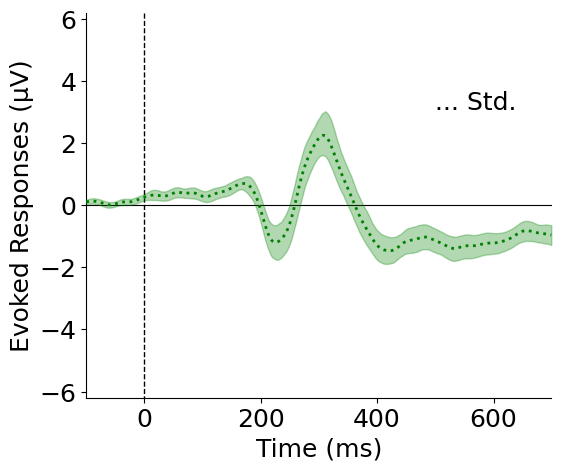

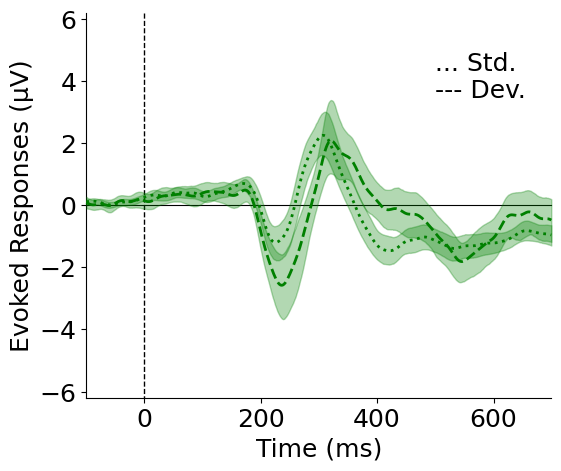

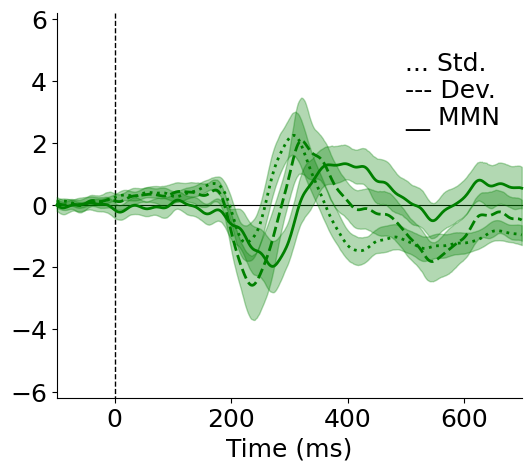

In [ ]:
# ### Personalized siginificant ERP for all the categories
picks= ['F3', 'Cz', 'F4',]
evokeds = {
    'PS std':B2_sta_eps_evoked_list,
           
           }

# Subset the evoked data by selecting the time range
evokeds_subset = {}
for cond in evokeds:
    evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
    evokeds_subset[cond]  =evoked_crop 

# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)

stylesdict ={
             'PS std' : {"linewidth": 2,"linestyle":'dotted'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.75,0.750, f"... Std.", transform=axs.transAxes, fontsize=18)
axs.set_ylabel('Evoked Responses (µV)')
 
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
           'Ps deviant': B1_devi_eps_evoked_list,
           'PS std':B2_sta_eps_evoked_list,
                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}
for cond in evokeds:
    evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
    evokeds_subset[cond]  =evoked_crop 


stylesdict ={'Ps deviant': {"linewidth": 2,"linestyle":'--'},
             'PS std' : {"linewidth": 2,"linestyle":'dotted'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green','green'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title=  '')
axs.text( 0.75,0.85, f"... Std.", transform=axs.transAxes, fontsize=18)
axs.text( 0.75,0.78, f"--- Dev.", transform=axs.transAxes, fontsize=18)
axs.set_ylabel('Evoked Responses (µV)')
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
           'Ps deviant': B1_devi_eps_evoked_list,
           'PS std':B2_sta_eps_evoked_list,
           'PS MMN': Personal_MMN_evokeds_list,
                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}
for cond in evokeds:
    evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
    evokeds_subset[cond]  =evoked_crop 



stylesdict ={'Ps deviant': {"linewidth": 2,"linestyle":'--'},
             'PS std' : {"linewidth": 2,"linestyle":'dotted'},
             'PS MMN' :  {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green','green','green'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes=axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title='')
axs.text( 0.75,0.85, f"... Std.", transform=axs.transAxes, fontsize=18)
axs.text( 0.75,0.78, f"--- Dev.", transform=axs.transAxes, fontsize=18)
axs.text( 0.75,0.71, f"__ MMN", transform=axs.transAxes, fontsize=18)
axs.set_ylabel('')
plt.rcParams.update({
    'xtick.labelsize': 18,  # X-axis tick labels font size
    'ytick.labelsize': 18,  # Y-axis tick labels font size
    'axes.labelsize': 18,   # Axis label font size
    'axes.titlesize': 18,   # Title font size 
    'legend.fontsize': 18,   # Legend font size
})
plt.show( )# export it 

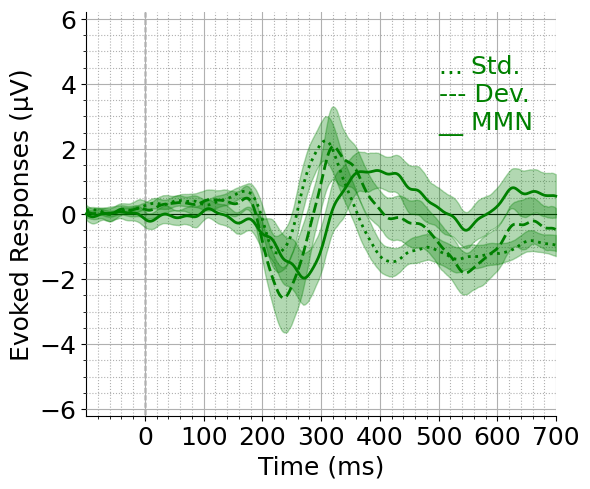

In [ ]:
evokeds = {
           'Ps deviant': B1_devi_eps_evoked_list,
           'PS std':B2_sta_eps_evoked_list,
           'PS MMN': Personal_MMN_evokeds_list,
                      }
# Subset the evoked data by selecting the time range
stylesdict ={'Ps deviant': {"linewidth": 2,"linestyle":'--','color':'green'},
             'PS std' : {"linewidth": 2,"linestyle":'dotted','color':'green'},
             'PS MMN' :  {"linewidth": 2,"linestyle":'solid','color':'green'},
             }

text_labels = [
    (0.85, "... Std.",'green'),
    (0.78, "--- Dev.",'green'),
    (0.71, "__ MMN",'green')
]

# Call the function
fig, axs = plot_erps(evokeds, picks=[ 'Cz'],
                                   stylesdict=stylesdict,
                                   text_labels=text_labels)
plt.show()

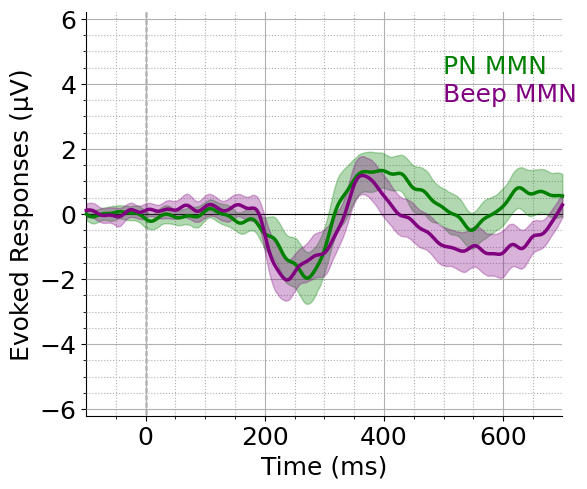

In [323]:
evokeds = {
    "PN MMN" : Personal_MMN_evokeds_list,
    'Beep MMN':non_sign_MMN_evokeds_list,
           }



stylesdict ={"PN MMN": {"linewidth": 2.5,"linestyle":'solid','color': 'green'},
             'Beep MMN' : {"linewidth": 2.5,"linestyle":'solid', 'color': 'purple'},
             }
# Call the function
text_labels = [
    (0.85, "PN MMN",'green'), 
    (0.78, "Beep MMN",'purple'),
]

fig, axs = plot_erps(evokeds, picks=[ 'Cz'],
                                   stylesdict=stylesdict,
                                   text_labels=text_labels)
plt.show()

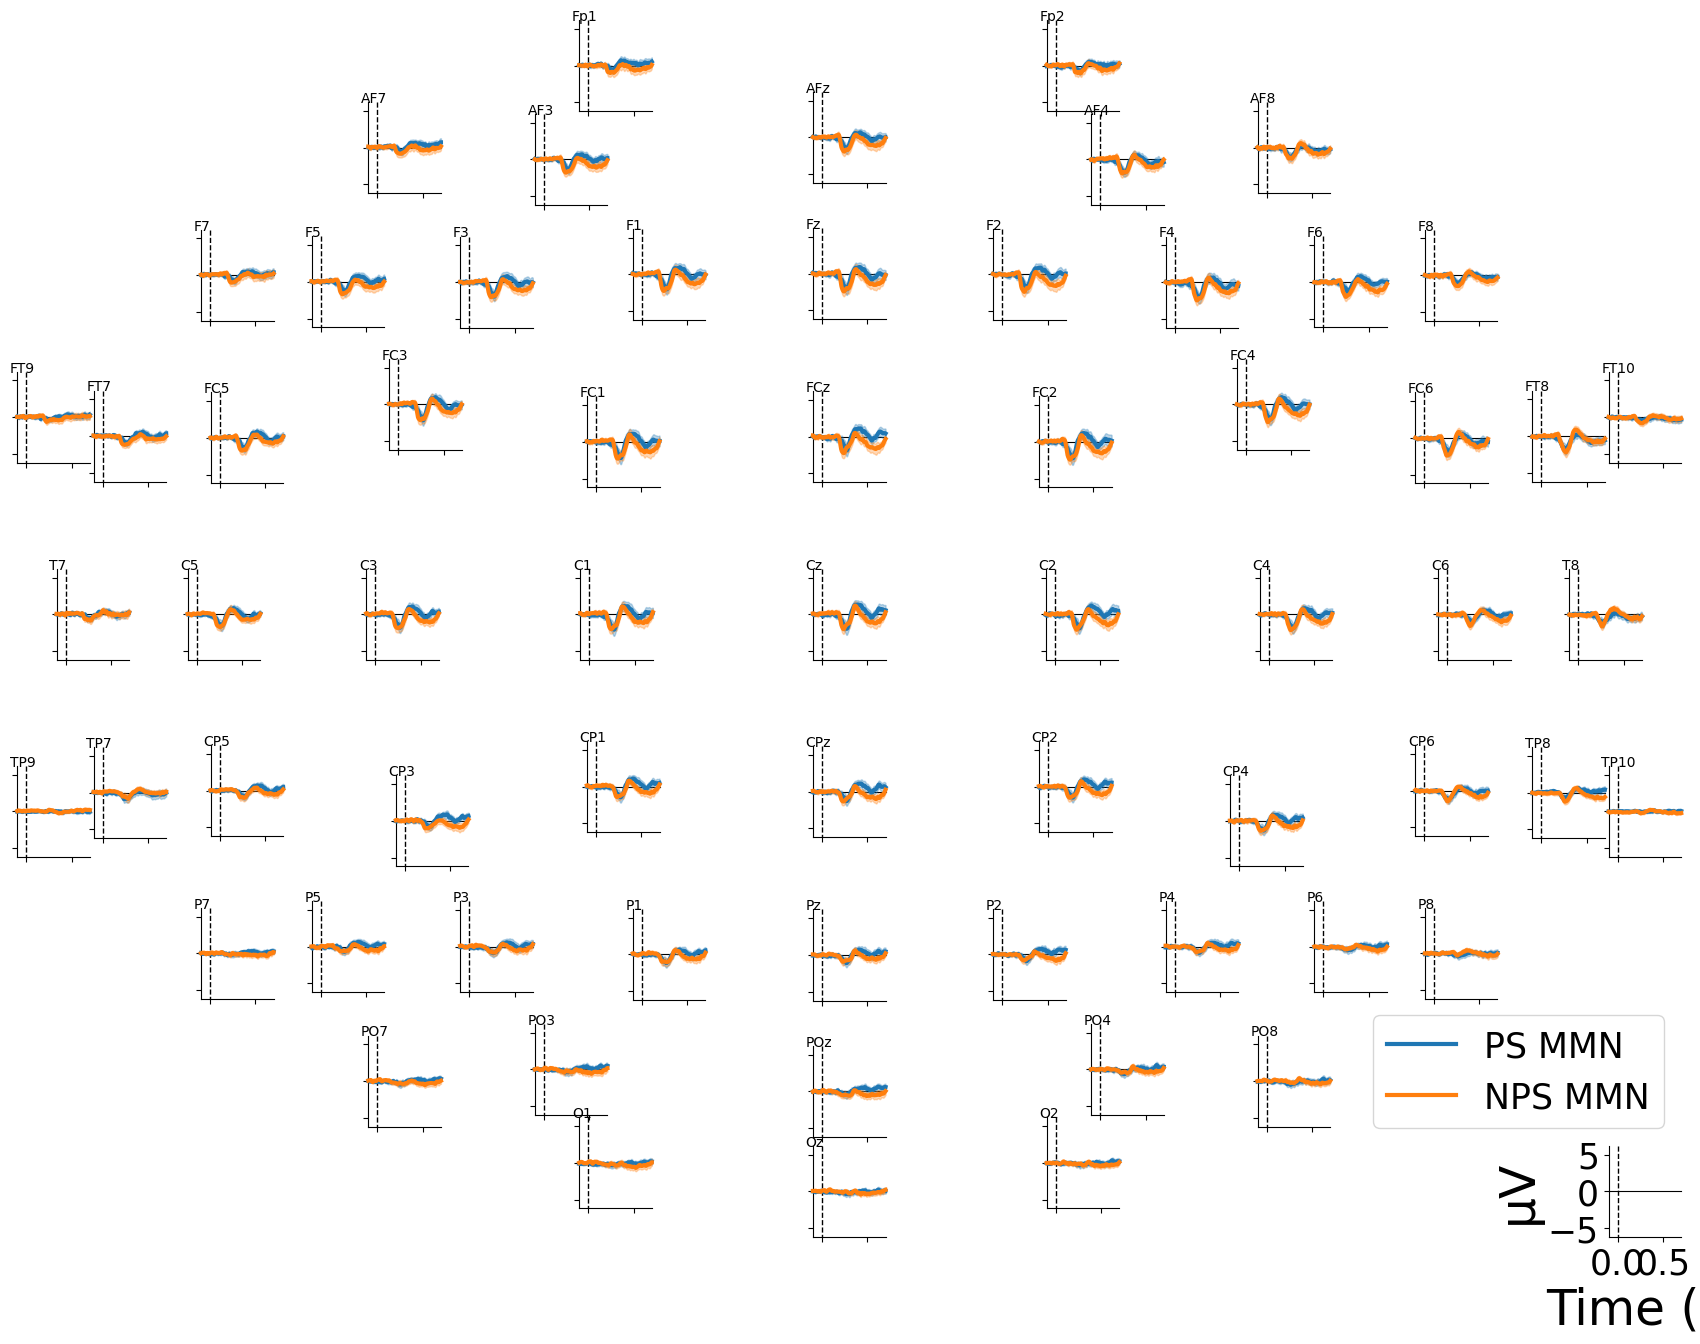

[<Figure size 1800x1400 with 65 Axes>]

In [16]:
stylesdict ={"PS MMN": {"linewidth": 3,"linestyle":'solid'},
             'NPS MMN' : {"linewidth": 3,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset,axes='topo',styles = stylesdict,
                             truncate_xaxis=False,truncate_yaxis=False,
                             ylim = dict(eeg=[-6.2,6.2]))

23 23


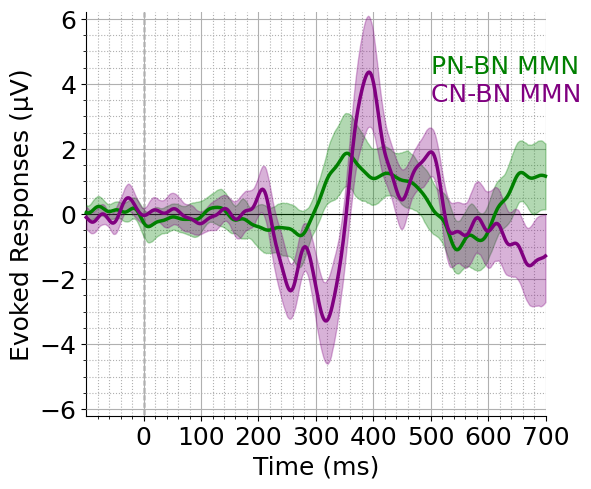

In [263]:

CN_sign_MMN_evokeds_list = [
    mne.combine_evoked([CN_devi_eps_evoked_dict[sub], CN_sta_eps_evoked_dict[sub]], weights=[1, -1])
    for sub in CN_devi_eps_evoked_dict if sub in B1_devi_eps_evoked_dict.keys()
]
PN_MMN_evokeds_list = [
    mne.combine_evoked([B1_devi_eps_evoked_dict[sub], B1_sta_eps_evoked_dict[sub]], weights=[1, -1])
    for sub in CN_devi_eps_evoked_dict if sub in B1_devi_eps_evoked_dict.keys()
]
print(len(PN_MMN_evokeds_list),len(CN_sign_MMN_evokeds_list))
evokeds = {
    "PN MMN" : PN_MMN_evokeds_list,
    'CN MMN':CN_sign_MMN_evokeds_list,
               }
# Subset the evoked data by selecting the time range



stylesdict ={"PN MMN": {"linewidth": 2.5,"linestyle":'solid','color': 'green'},
             'CN MMN' : {"linewidth": 2.5,"linestyle":'solid','color': 'purple'},
             }
# Call the function
text_labels = [
    (0.85, "PN-BN MMN",'green'),
    (0.78, "CN-BN MMN",'purple'),
]

fig, axs = plot_erps(evokeds, picks=[ 'Cz'],
                                   stylesdict=stylesdict,
                                   text_labels=text_labels)
plt.show()

### Subjectwise ERPs

In [18]:
B1_devi_eps_evoked_dict.keys()

dict_keys(['sub-sd011', 'sub-sd012', 'sub-sd013', 'sub-sd014', 'sub-sd015', 'sub-sd016', 'sub-sd017', 'sub-sd018', 'sub-sd019', 'sub-sd020', 'sub-sd021', 'sub-sd022', 'sub-sd023', 'sub-sd024', 'sub-sd025', 'sub-sd026', 'sub-sd027', 'sub-sd028', 'sub-sd029', 'sub-sd030', 'sub-sd031', 'sub-sd032', 'sub-sd033', 'sub-sd034', 'sub-sd035', 'sub-sd036', 'sub-sd037', 'sub-sd038', 'sub-sd039', 'sub-sd040', 'sub-sd042', 'sub-sd043', 'sub-sd044', 'sub-sd045', 'sub-sd047', 'sub-sd048', 'sub-sd049', 'sub-sd050', 'sub-sd051', 'sub-sd053', 'sub-sd054', 'sub-sd055', 'sub-sd056', 'sub-sd057', 'sub-sd059', 'sub-sd060', 'sub-sd061', 'sub-sd062', 'sub-sd063', 'sub-sd064', 'sub-sd065', 'sub-sd066', 'sub-sd067'])

In [358]:
Personal_MMN_evokeds_dict = {
    sub : mne.combine_evoked([B1_devi_eps_evoked_dict[sub], B2_sta_eps_evoked_dict[sub]], weights=[1, -1]) 
    for sub in B1_devi_eps_evoked_dict
    }



non_sign_MMN_evokeds_dict ={
    sub : mne.combine_evoked([B2_devi_eps_evoked_dict[sub], B1_sta_eps_evoked_dict[sub]], weights=[1, -1])
    for sub in B2_devi_eps_evoked_dict
}


In [ ]:

stylesdict ={"PS MMN": {"linewidth": 2,"linestyle":'solid'},
             'NPS MMN' : {"linewidth": 2,"linestyle":'solid'},
             }

for (PN_key, PN_value), (NPN_key, NPN_value) in zip(Personal_MMN_evokeds_dict.items(), non_sign_MMN_evokeds_dict.items()):


    fig,axs = plt.subplots(1,figsize=(5, 5), dpi =100)
    evokeds = {
        "PS MMN" :PN_value,
        'NPS MMN':NPN_value,
           }
    # Subset the evoked data by selecting the time range
    
    mne.viz.plot_compare_evokeds(evokeds, picks=picks[1],colors = ['green', 'Purple'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title=PN_key)
    axs.text( 0.70,0.85, f"Beep MMN", transform=axs.transAxes, fontsize=18, color='Purple')
    axs.text( 0.72,0.78, f"SN MMN", transform=axs.transAxes, fontsize=18, color='green')
    axs.set_ylabel('Evoked Responses (µV)')
    # Set major ticks and grid
    axs.set_xticks(np.arange(0, 800, 100))  # Ticks every 0.5 units
    #axs.set_yticks(np.arange(-1, 1.1, 0.2)) # Ticks every 0.2 units
    axs.grid(which='major', linestyle='-')

    # Enable minor ticks and grid
    axs.minorticks_on()
    axs.grid(which='minor', linestyle=':')
    plt.rcParams.update({
        'xtick.labelsize': 10,  # X-axis tick labels font size
        'ytick.labelsize': 18,  # Y-axis tick labels font size
        'axes.labelsize': 18,   # Axis label font size
        'axes.titlesize': 18,   # Title font size 
        'legend.fontsize': 18,   # Legend font size
        })
    # Plot the evoked responses
    plt.show()

In [ ]:
for evk in pn_new_shift:


    fig,axs = plt.subplots(1,figsize=(5, 5), dpi =100)
    
    # Subset the evoked data by selecting the time range
    
    mne.viz.plot_compare_evokeds(evk, picks=picks[1],colors = ['green', 'Purple'],show_sensors=False,legend=False,
                                    combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title=PN_key)
    
    axs.text( 0.72,0.78, f"SN MMN", transform=axs.transAxes, fontsize=18, color='green')
    axs.set_ylabel('Evoked Responses (µV)')
    # Set major ticks and grid
    #axs.set_xticks(np.arange(0, 800, 100))  # Ticks every 0.5 units
    #axs.set_yticks(np.arange(-1, 1.1, 0.2)) # Ticks every 0.2 units
    axs.grid(which='major', linestyle='-')

    # Enable minor ticks and grid
    axs.minorticks_on()
    axs.grid(which='minor', linestyle=':')
    plt.rcParams.update({
        'xtick.labelsize': 10,  # X-axis tick labels font size
        'ytick.labelsize': 18,  # Y-axis tick labels font size
        'axes.labelsize': 18,   # Axis label font size
        'axes.titlesize': 18,   # Title font size 
        'legend.fontsize': 18,   # Legend font size
        })
    # Plot the evoked responses
    plt.show()

In [ ]:
import numpy as np
from mne.evoked import Evoked
from typing import List
from mne import EvokedArray
import random
pn_new_shift  = [evk.copy().shift_time(-random.uniform(0.140, 0.320)) for evk in Personal_MMN_evokeds_dict.values()]
beep_new_shift = [evk.copy().shift_time(-random.uniform(0.140, 0.320)) for evk in non_sign_MMN_evokeds_dict.values()]
def update_evoked_times(evokeds: List[Evoked], atol: float = 1e-6) -> None:
    """
    Update the `.times` array of each Evoked object so that:
      - The time point closest to zero is set to 0.0,
      - All time points after it are updated based on sampling frequency,
      - Time points before zero are left unchanged.

    Parameters
    ----------
    evokeds : list of mne.Evoked
        List of Evoked objects to update in-place.
    atol : float
        Absolute tolerance to determine closeness to zero.
    """
    updated_evokeds = []
    for evoked in evokeds:
        times = evoked.times.copy()
        sfreq = evoked.info['sfreq']
        dt = 1.0 / sfreq

        # Find index closest to zero
        zero_idx = np.argmin(np.abs(times))
        
        # Safety check
        if not np.isclose(times[zero_idx], 0.0, atol=atol):
            print(f"Warning: Closest value to zero is {times[zero_idx]:.6f}, not within atol={atol}")

        new_tmin = -zero_idx * dt

        # Create new evoked with same data, info, and updated tmin
        new_evoked = EvokedArray(evoked.data, evoked.info, tmin=new_tmin, nave=evoked.nave,
                                 comment=evoked.comment, kind=evoked.kind)
        updated_evokeds.append(new_evoked)
    return updated_evokeds


new_pn_updated_lst = update_evoked_times(pn_new_shift)

new_beep_updated_lst = update_evoked_times(beep_new_shift)

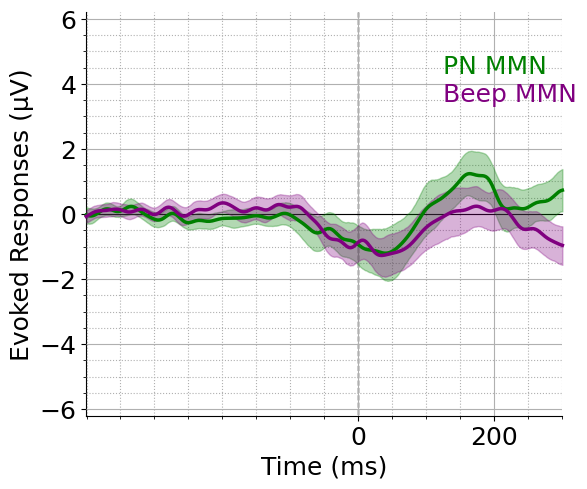

In [506]:
evokeds = {
    "PN MMN" : new_pn_updated_lst,
    'Beep MMN':new_beep_updated_lst,
           }



stylesdict ={"PN MMN": {"linewidth": 2.5,"linestyle":'solid','color': 'green'},
             'Beep MMN' : {"linewidth": 2.5,"linestyle":'solid', 'color': 'purple'},
             }
# Call the function
text_labels = [
    (0.85, "PN MMN",'green'), 
    (0.78, "Beep MMN",'purple'),
]

fig, axs = plot_erps(evokeds, picks=[ 'Cz'],time_range=(-.400,.300),
                                   stylesdict=stylesdict,
                                   text_labels=text_labels)
plt.show()

In [483]:
-2.08540817e-04

-0.000208540817

In [457]:
for evoked in evokeds_subset['pn_new_shift']:
    print(evoked.pick(["Cz"]).times[:10])

[-0.30098979 -0.29903667 -0.29708354 -0.29513042 -0.29317729 -0.29122417
 -0.28927104 -0.28731792 -0.28536479 -0.28341167]
[-0.30117716 -0.29922403 -0.29727091 -0.29531778 -0.29336466 -0.29141153
 -0.28945841 -0.28750528 -0.28555216 -0.28359903]
[-0.30130581 -0.29935268 -0.29739956 -0.29544643 -0.29349331 -0.29154018
 -0.28958706 -0.28763393 -0.28568081 -0.28372768]
[-0.30144062 -0.2994875  -0.29753437 -0.29558125 -0.29362812 -0.291675
 -0.28972187 -0.28776875 -0.28581562 -0.2838625 ]
[-0.30062166 -0.29866853 -0.29671541 -0.29476228 -0.29280916 -0.29085603
 -0.28890291 -0.28694978 -0.28499666 -0.28304353]
[-0.30009165 -0.29813852 -0.2961854  -0.29423227 -0.29227915 -0.29032602
 -0.2883729  -0.28641977 -0.28446665 -0.28251352]
[-0.30046483 -0.2985117  -0.29655858 -0.29460545 -0.29265233 -0.2906992
 -0.28874608 -0.28679295 -0.28483983 -0.2828867 ]
[-0.30071461 -0.29876148 -0.29680836 -0.29485523 -0.29290211 -0.29094898
 -0.28899586 -0.28704273 -0.28508961 -0.28313648]
[-0.30140606 -0.299

In [ ]:
for evk in evokeds_subset['pn_new_shift']:


    fig,axs = plt.subplots(1,figsize=(5, 5), dpi =100)
    
    # Subset the evoked data by selecting the time range
    
    mne.viz.plot_compare_evokeds(evk, picks=picks[1],colors = ['green', 'Purple'],show_sensors=False,legend=False,
                                    combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title=PN_key)
    
    axs.text( 0.72,0.78, f"SN MMN", transform=axs.transAxes, fontsize=18, color='green')
    axs.set_ylabel('Evoked Responses (µV)')
    # Set major ticks and grid
    #axs.set_xticks(np.arange(0, 800, 100))  # Ticks every 0.5 units
    #axs.set_yticks(np.arange(-1, 1.1, 0.2)) # Ticks every 0.2 units
    axs.grid(which='major', linestyle='-')

    # Enable minor ticks and grid
    axs.minorticks_on()
    axs.grid(which='minor', linestyle=':')
    plt.rcParams.update({
        'xtick.labelsize': 10,  # X-axis tick labels font size
        'ytick.labelsize': 18,  # Y-axis tick labels font size
        'axes.labelsize': 18,   # Axis label font size
        'axes.titlesize': 18,   # Title font size 
        'legend.fontsize': 18,   # Legend font size
        })
    # Plot the evoked responses
    plt.show()

In [ ]:
    fig,axs = plt.subplots(1,figsize=(5, 5), dpi =100)
    
    # Subset the evoked data by selecting the time range
    
    mne.viz.plot_compare_evokeds(evokeds_subset['pn_new_shift'], picks=picks[1],colors = ['green', 'Purple'],show_sensors=False,legend=False,
                                    combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title=PN_key)
    
    axs.text( 0.72,0.78, f"SN MMN", transform=axs.transAxes, fontsize=18, color='green')
    axs.set_ylabel('Evoked Responses (µV)')
    # Set major ticks and grid
    #axs.set_xticks(np.arange(0, 800, 100))  # Ticks every 0.5 units
    #axs.set_yticks(np.arange(-1, 1.1, 0.2)) # Ticks every 0.2 units
    axs.grid(which='major', linestyle='-')

    # Enable minor ticks and grid
    axs.minorticks_on()
    axs.grid(which='minor', linestyle=':')
    plt.rcParams.update({
        'xtick.labelsize': 10,  # X-axis tick labels font size
        'ytick.labelsize': 18,  # Y-axis tick labels font size
        'axes.labelsize': 18,   # Axis label font size
        'axes.titlesize': 18,   # Title font size 
        'legend.fontsize': 18,   # Legend font size
        })
    # Plot the evoked responses
    plt.show()

ValueError: <Evoked | '10005 - 10007' (average, N=73.10469314079423), -0.30099 – 0.30057 s, baseline -0.300781 – 0 s, 64 ch, ~234 kB> and <Evoked | '10005 - 10007' (average, N=118.27327690447402), -0.30118 – 0.30039 s, baseline -0.300781 – 0 s, 64 ch, ~234 kB> do not contain the same time instants

### Type of Notification and ERP

In [300]:
delayed_tone = ['sub-sd012', 'sub-sd014', 'sub-sd016', 'sub-sd020', 'sub-sd027', 'sub-sd032', 'sub-sd033',
                 'sub-sd036', 'sub-sd038', 'sub-sd044', 'sub-sd051', 'sub-sd055', 'sub-sd067']
regu_tone = ['sub-sd011','sub-sd013', 'sub-sd015', 'sub-sd017', 'sub-sd018', 'sub-sd019', 'sub-sd021', 'sub-sd022', 'sub-sd023',
              'sub-sd024', 'sub-sd025', 'sub-sd026', 'sub-sd028', 'sub-sd029', 'sub-sd030', 'sub-sd031', 'sub-sd035', 'sub-sd037',
                'sub-sd041', 'sub-sd042', 'sub-sd043', 'sub-sd045', 'sub-sd046', 'sub-sd047', 'sub-sd048', 'sub-sd049', 'sub-sd052',
                  'sub-sd053', 'sub-sd054', 'sub-sd056', 'sub-sd057', 'sub-sd058', 'sub-sd060','sub-sd061','sub-sd062', 'sub-sd063', 'sub-sd064',
                    'sub-sd065', 'sub-sd066']

outliar_tone = ['sub-sd034', 'sub-sd039', 'sub-sd040', 'sub-sd050', 'sub-sd059'] 

In [ ]:

dur_tone_groups = {
    'delayed_tone': delayed_tone,
    'regu_tone': regu_tone,
    'outliar_tone': outliar_tone,
}
tone_based_PN_MMN_evokes = {key: [] for key in dur_tone_groups}

# Assign evokeds to the appropriate group
for sub, evoked in Personal_MMN_evokeds_dict.items():
    for group_name, subject_list in dur_tone_groups.items():
        if sub in subject_list:
            tone_based_PN_MMN_evokes[group_name].append(evoked)
            break


tone_based_non_sign_MMN_evokes = {key: [] for key in dur_tone_groups}

# Assign evokeds to the appropriate group
for sub, evoked in non_sign_MMN_evokeds_dict.items():
    for group_name, subject_list in dur_tone_groups.items():
        if sub in subject_list:
            tone_based_non_sign_MMN_evokes[group_name].append(evoked)
            break

tone_based_PN_devi_evokes = {key: [] for key in dur_tone_groups}

# Assign evokeds to the appropriate group
for sub, evoked in B1_devi_eps_evoked_dict.items():
    for group_name, subject_list in dur_tone_groups.items():
        if sub in subject_list:
            tone_based_PN_devi_evokes[group_name].append(evoked)
            break

tone_based_PN_std_evokes = {key: [] for key in dur_tone_groups}

# Assign evokeds to the appropriate group
for sub, evoked in B2_sta_eps_evoked_dict.items():
    for group_name, subject_list in dur_tone_groups .items():
        if sub in subject_list:
            tone_based_PN_std_evokes[group_name].append(evoked)
            break


Statistical test results:
overall: t=2.728, p=0.009
channel_0: t=2.117, p=0.039
channel_1: t=3.191, p=0.002
channel_2: t=2.577, p=0.013


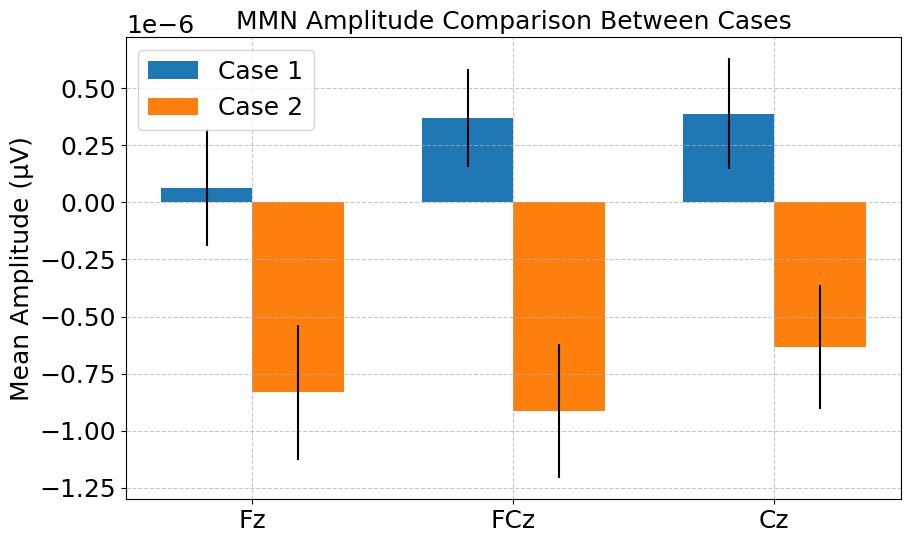

In [304]:
# Define parameters
time_window = (400, 580)  # MMN typically 100-250ms
channels = ['Fz', 'FCz', 'Cz']  # Common MMN channels

# Extract amplitudes
case1_amps, case2_amps, subjects = extract_mmn_amplitudes(
    Personal_MMN_evokeds_dict ,non_sign_MMN_evokeds_dict , time_window=time_window, channels=channels
)

# Run statistical tests
results = run_statistical_tests(case1_amps, case2_amps)
print("Statistical test results:")
for key, data in results.items():
    print(f"{key}: t={data['t_stat']:.3f}, p={data['p_value']:.3f}")

# Visualize
fig = visualize_results(case1_amps, case2_amps, subjects, channel_names=channels)
plt.show()


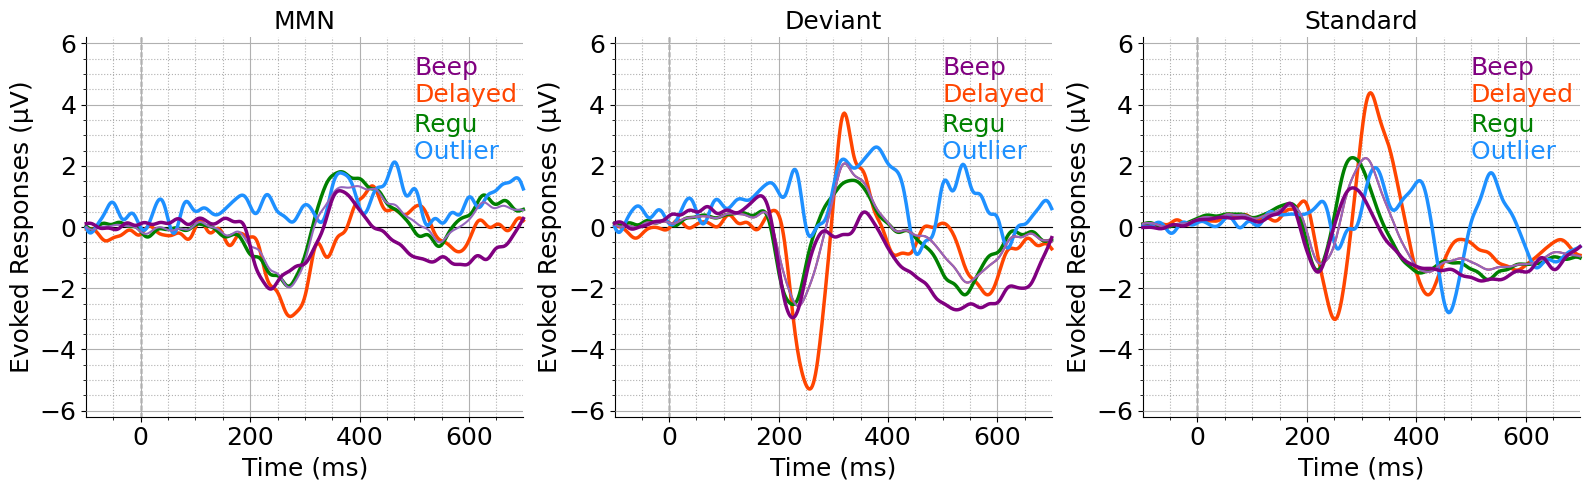

In [331]:
stylesdict ={"delayed_tone": {"linewidth": 2.5,"linestyle":'solid','color' : 'orangered'},
             'regu_tone' : {"linewidth": 2.5,"linestyle":'solid','color' : 'green'},
             'outliar_tone': {"linewidth": 2.5,"linestyle":'solid','color' : 'dodgerblue'},
             "Beep": {"linewidth": 2.5,"linestyle":'solid','color' : 'purple'},
             }
text_labels = [
    (0.90, "Beep",'purple'),
    (0.83, f"Delayed",'orangered'),
    (0.75, f"Regu ",'green'),
    (0.68, f"Outlier ",'dodgerblue')
]
# Example usage with subplots
fig, axs = plt.subplots(1, 3, figsize=(16, 5), dpi=100)

# Define first ERP comparison
evokeds = tone_based_PN_MMN_evokes
evokeds["Beep"] = non_sign_MMN_evokeds_list
plot_erps(evokeds, picks=[ 'Cz'],
                                   stylesdict=stylesdict,
                                   text_labels=text_labels,ci=False,title="MMN",axs=axs[0])

# Define second ERP comparison
evokeds = tone_based_PN_devi_evokes
evokeds["Beep"] = B2_devi_eps_evoked_list
plot_erps(evokeds, picks=[ 'Cz'],
                                   stylesdict=stylesdict,
                                   text_labels=text_labels,ci=False,title="Deviant",axs=axs[1])


evokeds = tone_based_PN_std_evokes 
evokeds["Beep"] = B1_sta_eps_evoked_list
plot_erps(evokeds, picks=[ 'Cz'],
                                   stylesdict=stylesdict,
                                   text_labels=text_labels,ci=False,title="Standard",axs=axs[2])
plt.tight_layout()
plt.show()


In [332]:

whoop_tone = ['sub-sd012', 'sub-sd016','sub-sd036', 'sub-sd038' ,'sub-sd051','sub-sd067']
iphonr_tone = [ 'sub-sd019','sub-sd028', 'sub-sd031', 'sub-sd035','sub-sd043', 'sub-sd045','sub-sd052', 'sub-sd065',]
spaceLine_tone = ['sub-sd017', 'sub-sd026', 'sub-sd046', 'sub-sd047','sub-sd054','sub-sd063']
moto_tone = ['sub-sd011','sub-sd013',  'sub-sd018','sub-sd048','sub-sd056', ]


type_tone_groups = {
    'whoop_tone': whoop_tone,
    'iphonr_tone': iphonr_tone,
    'spaceLine_tone': spaceLine_tone,
    'moto_tone' :moto_tone,
}
type_tone_based_PN_MMN_evokes = {key: [] for key in type_tone_groups}

# Assign evokeds to the appropriate group
for sub, evoked in Personal_MMN_evokeds_dict.items():
    for group_name, subject_list in type_tone_groups.items():
        if sub in subject_list:
            type_tone_based_PN_MMN_evokes[group_name].append(evoked)
            break


type_tone_based_non_sign_MMN_evokes = {key: [] for key in type_tone_groups}

# Assign evokeds to the appropriate group
for sub, evoked in non_sign_MMN_evokeds_dict.items():
    for group_name, subject_list in type_tone_groups.items():
        if sub in subject_list:
            type_tone_based_non_sign_MMN_evokes[group_name].append(evoked)
            break

type_tone_based_PN_devi_evokes = {key: [] for key in type_tone_groups}

# Assign evokeds to the appropriate group
for sub, evoked in B1_devi_eps_evoked_dict.items():
    for group_name, subject_list in type_tone_groups.items():
        if sub in subject_list:
            type_tone_based_PN_devi_evokes[group_name].append(evoked)
            break

type_tone_based_PN_std_evokes = {key: [] for key in type_tone_groups}

# Assign evokeds to the appropriate group
for sub, evoked in B2_sta_eps_evoked_dict.items():
    for group_name, subject_list in type_tone_groups.items():
        if sub in subject_list:
            type_tone_based_PN_std_evokes[group_name].append(evoked)
            break


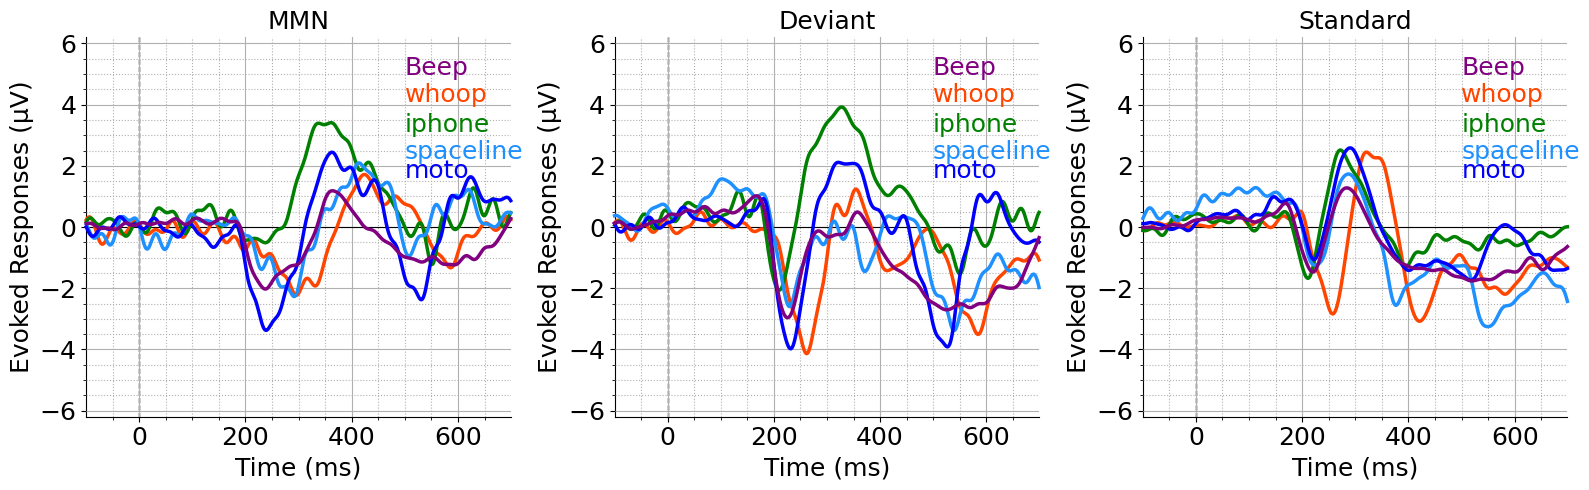

In [338]:
stylesdict ={"whoop_tone": {"linewidth": 2.5,"linestyle":'solid','color' : 'orangered'},
             'iphonr_tone' : {"linewidth": 2.5,"linestyle":'solid','color' : 'green'},
             'spaceLine_tone': {"linewidth": 2.5,"linestyle":'solid','color' : 'dodgerblue'},
             "Beep": {"linewidth": 2.5,"linestyle":'solid','color' : 'purple'},
             "moto_tone": {"linewidth": 2.5,"linestyle":'solid','color' : 'blue'},
             }

type_tone_groups = {
    'whoop_tone': whoop_tone,
    'iphonr_tone': iphonr_tone,
    'spaceLine_tone': spaceLine_tone,
    'moto_tone' :moto_tone,
}
text_labels = [
    (0.90, "Beep",'purple'),
    (0.83, f"whoop",'orangered'),
    (0.75, f"iphone",'green'),
    (0.68, f"spaceline",'dodgerblue'),
    (0.63, f"moto",'blue')
]
# Example usage with subplots
fig, axs = plt.subplots(1, 3, figsize=(16, 5), dpi=100)

# Define first ERP comparison
evokeds = type_tone_based_PN_MMN_evokes
evokeds["Beep"] = non_sign_MMN_evokeds_list
plot_erps(evokeds, picks=[ 'Cz'],
                                   stylesdict=stylesdict,
                                   text_labels=text_labels,ci=False,title="MMN",axs=axs[0])

# Define second ERP comparison
evokeds = type_tone_based_PN_devi_evokes
evokeds["Beep"] = B2_devi_eps_evoked_list
plot_erps(evokeds, picks=[ 'Cz'],
                                   stylesdict=stylesdict,
                                   text_labels=text_labels,ci=False,title="Deviant",axs=axs[1])


evokeds = type_tone_based_PN_std_evokes 
evokeds["Beep"] = B1_sta_eps_evoked_list
plot_erps(evokeds, picks=[ 'Cz'],
                                   stylesdict=stylesdict,
                                   text_labels=text_labels,ci=False,title="Standard",axs=axs[2])
plt.tight_layout()
plt.show()

In [339]:
evokeds

{'whoop_tone': [<Evoked | '10007' (average, N=684), -0.30078 – 0.69922 s, baseline -0.300781 – 0 s, 64 ch, ~336 kB>,
  <Evoked | '10007' (average, N=750), -0.30078 – 0.69922 s, baseline -0.300781 – 0 s, 64 ch, ~336 kB>,
  <Evoked | '10007' (average, N=747), -0.30078 – 0.69922 s, baseline -0.300781 – 0 s, 64 ch, ~336 kB>,
  <Evoked | '10007' (average, N=617), -0.30078 – 0.69922 s, baseline -0.300781 – 0 s, 64 ch, ~336 kB>,
  <Evoked | '10005' (average, N=562), -0.30078 – 0.69922 s, baseline -0.300781 – 0 s, 64 ch, ~336 kB>,
  <Evoked | '10005' (average, N=687), -0.30078 – 0.69922 s, baseline -0.300781 – 0 s, 64 ch, ~336 kB>],
 'iphonr_tone': [<Evoked | '10007' (average, N=504), -0.30078 – 0.69922 s, baseline -0.300781 – 0 s, 64 ch, ~336 kB>,
  <Evoked | '10007' (average, N=733), -0.30078 – 0.69922 s, baseline -0.300781 – 0 s, 64 ch, ~336 kB>,
  <Evoked | '10007' (average, N=735), -0.30078 – 0.69922 s, baseline -0.300781 – 0 s, 64 ch, ~336 kB>,
  <Evoked | '10007' (average, N=700), -0.30

In [25]:
for k,v in tone_based_PN_MMN_evokes.items():
    print(k, len(v))
print(Personal_MMN_evokeds_dict.keys())    

delayed_tone 13
regu_tone 35
outliar_tone 5
Beep MMN 53
dict_keys(['sub-sd011', 'sub-sd012', 'sub-sd013', 'sub-sd014', 'sub-sd015', 'sub-sd016', 'sub-sd017', 'sub-sd018', 'sub-sd019', 'sub-sd020', 'sub-sd021', 'sub-sd022', 'sub-sd023', 'sub-sd024', 'sub-sd025', 'sub-sd026', 'sub-sd027', 'sub-sd028', 'sub-sd029', 'sub-sd030', 'sub-sd031', 'sub-sd032', 'sub-sd033', 'sub-sd034', 'sub-sd035', 'sub-sd036', 'sub-sd037', 'sub-sd038', 'sub-sd039', 'sub-sd040', 'sub-sd042', 'sub-sd043', 'sub-sd044', 'sub-sd045', 'sub-sd047', 'sub-sd048', 'sub-sd049', 'sub-sd050', 'sub-sd051', 'sub-sd053', 'sub-sd054', 'sub-sd055', 'sub-sd056', 'sub-sd057', 'sub-sd059', 'sub-sd060', 'sub-sd061', 'sub-sd062', 'sub-sd063', 'sub-sd064', 'sub-sd065', 'sub-sd066', 'sub-sd067'])


# Smartphone usage based group

In [274]:
low_sub_D  = ['sd011', 'sd012', 'sd013', 'sd014', 'sd017', 'sd019', 'sd020', 'sd021', 'sd023', 'sd024', 'sd025', 'sd027', 'sd031',
               'sd032', 'sd043', 'sd044', 'sd045', 'sd046', 'sd047', 'sd048', 'sd052', 'sd053', 'sd057', 'sd060', 'sd061', 'sd063', 'sd064', 'sd065', 'sd067']
low_sub_D = ["sub-"+sub for sub in low_sub_D ]

high_sub_D = ['sd015', 'sd016', 'sd018', 'sd022', 'sd026', 'sd028', 'sd029', 'sd030', 'sd033', 'sd034', 'sd035', 'sd036', 'sd037',
               'sd038', 'sd039', 'sd040', 'sd041', 'sd042', 'sd049', 'sd050', 'sd051', 'sd054', 'sd055', 'sd056', 'sd058', 'sd059', 'sd062', 'sd066']
high_sub_D  = ["sub-"+sub for sub in high_sub_D  ]

### LSU and HSU MMN

In [276]:

B1_devi_eps_evoked_list_low = [B1_devi_eps_evoked_dict[sub] for sub in B1_devi_eps_evoked_dict if sub in low_sub_D]

B1_sta_eps_evoked_list_low = [B1_sta_eps_evoked_dict[sub] for sub in B1_sta_eps_evoked_dict if sub in low_sub_D]

B2_devi_eps_evoked_list_low =  [B2_devi_eps_evoked_dict[sub] for sub in B2_devi_eps_evoked_dict if sub in low_sub_D]

B2_sta_eps_evoked_list_low = [B2_sta_eps_evoked_dict[sub] for sub in B2_sta_eps_evoked_dict if sub in low_sub_D]
  
Personal_MMN_evokeds_list_low = [
    mne.combine_evoked([dev, std], weights=[1, -1])
    for dev, std in zip(B1_devi_eps_evoked_list_low, B2_sta_eps_evoked_list_low)
]



non_sign_MMN_evokeds_list_low = [
    mne.combine_evoked([dev, std], weights=[1, -1])
    for dev, std in zip(B2_devi_eps_evoked_list_low, B1_sta_eps_evoked_list_low)
] 



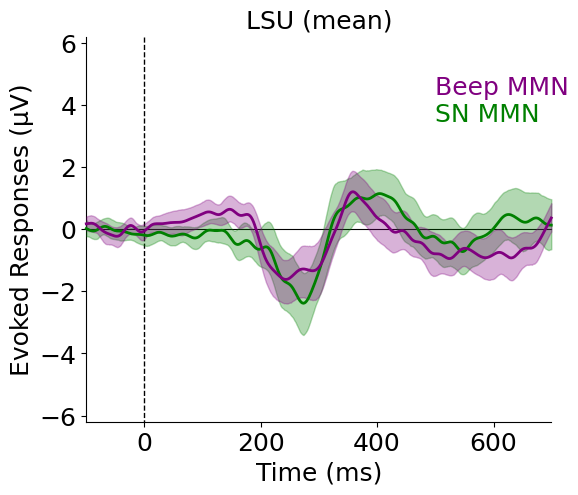

In [277]:
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
    "PS MMN" : Personal_MMN_evokeds_list_low,
    'NPS MMN':non_sign_MMN_evokeds_list_low,
           }
# Subset the evoked data by selecting the time range
evokeds_subset = {}
for cond in evokeds:
    evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
    evokeds_subset[cond]  =evoked_crop 



stylesdict ={"PS MMN": {"linewidth": 2,"linestyle":'solid'},
             'NPS MMN' : {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=['Cz','FCz','CPz','CP1','CP2','C2','C1','Fz',"Pz","FC1","FC2",],colors = ['green', 'Purple'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='LSU')
axs.text( 0.75,0.85, f"Beep MMN", transform=axs.transAxes, fontsize=18, color='Purple')
axs.text( 0.75,0.78, f"SN MMN", transform=axs.transAxes, fontsize=18, color='green')
axs.set_ylabel('Evoked Responses (µV)')
plt.rcParams.update({
    'xtick.labelsize': 18,  # X-axis tick labels font size
    'ytick.labelsize': 18,  # Y-axis tick labels font size
    'axes.labelsize': 18,   # Axis label font size
    'axes.titlesize': 18,   # Title font size 
    'legend.fontsize': 18,   # Legend font size
})
plt.show()

27 27


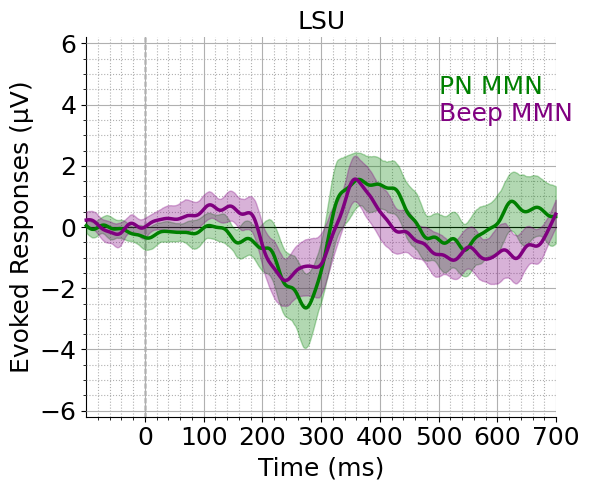

In [283]:
print(len(Personal_MMN_evokeds_list_low),len(non_sign_MMN_evokeds_list_low))
evokeds = {
    "PN MMN" : Personal_MMN_evokeds_list_low,
    'NPS MMN':non_sign_MMN_evokeds_list_low,
           }
# Subset the evoked data by selecting the time range





stylesdict ={"PN MMN": {"linewidth": 2.5,"linestyle":'solid','color': 'green'},
             'NPS MMN' : {"linewidth": 2.5,"linestyle":'solid','color': 'purple'},
             }
# Call the function
text_labels = [
    (0.85, "PN MMN",'green'),
    (0.78, "Beep MMN",'purple'),
]

fig, axs = plot_erps(evokeds, picks=[ 'Cz'],
                                   stylesdict=stylesdict,
                                   text_labels=text_labels,title='LSU')
plt.show()

In [69]:



B1_devi_eps_evoked_list_high = [B1_devi_eps_evoked_dict[sub] for sub in B1_devi_eps_evoked_dict if sub in high_sub_D]

B1_sta_eps_evoked_list_high = [B1_sta_eps_evoked_dict[sub] for sub in B1_sta_eps_evoked_dict if sub in high_sub_D]

B2_devi_eps_evoked_list_high =  [B2_devi_eps_evoked_dict[sub] for sub in B2_devi_eps_evoked_dict if sub in high_sub_D]

B2_sta_eps_evoked_list_high = [B2_sta_eps_evoked_dict[sub] for sub in B2_sta_eps_evoked_dict if sub in high_sub_D]
  
Personal_MMN_evokeds_list_high = [
    mne.combine_evoked([dev, std], weights=[1, -1])
    for dev, std in zip(B1_devi_eps_evoked_list_high, B2_sta_eps_evoked_list_high)
]



non_sign_MMN_evokeds_list_high = [
    mne.combine_evoked([dev, std], weights=[1, -1])
    for dev, std in zip(B2_devi_eps_evoked_list_high, B1_sta_eps_evoked_list_high)
] 



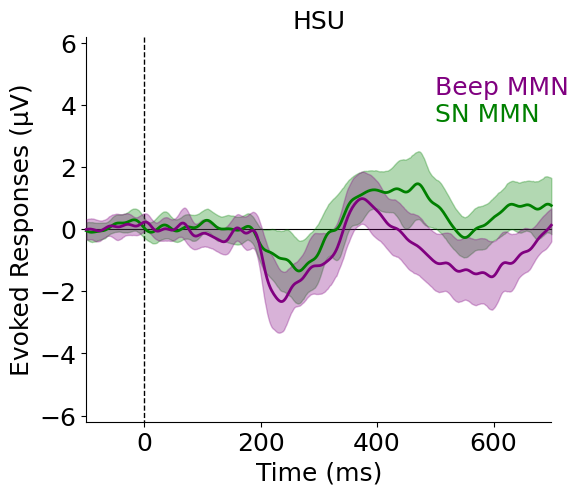

In [70]:
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
    "PS MMN" : Personal_MMN_evokeds_list_high,
    'NPS MMN':non_sign_MMN_evokeds_list_high,
           }
# Subset the evoked data by selecting the time range
evokeds_subset = {}
for cond in evokeds:
    evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
    evokeds_subset[cond]  =evoked_crop 




stylesdict ={"PS MMN": {"linewidth": 2,"linestyle":'solid'},
             'NPS MMN' : {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green', 'Purple'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='HSU')
axs.text( 0.75,0.85, f"Beep MMN", transform=axs.transAxes, fontsize=18, color='Purple')
axs.text( 0.75,0.78, f"SN MMN", transform=axs.transAxes, fontsize=18, color='green')
axs.set_ylabel('Evoked Responses (µV)')
plt.rcParams.update({
    'xtick.labelsize': 18,  # X-axis tick labels font size
    'ytick.labelsize': 18,  # Y-axis tick labels font size
    'axes.labelsize': 18,   # Axis label font size
    'axes.titlesize': 18,   # Title font size 
    'legend.fontsize': 18,   # Legend font size
})
plt.show()

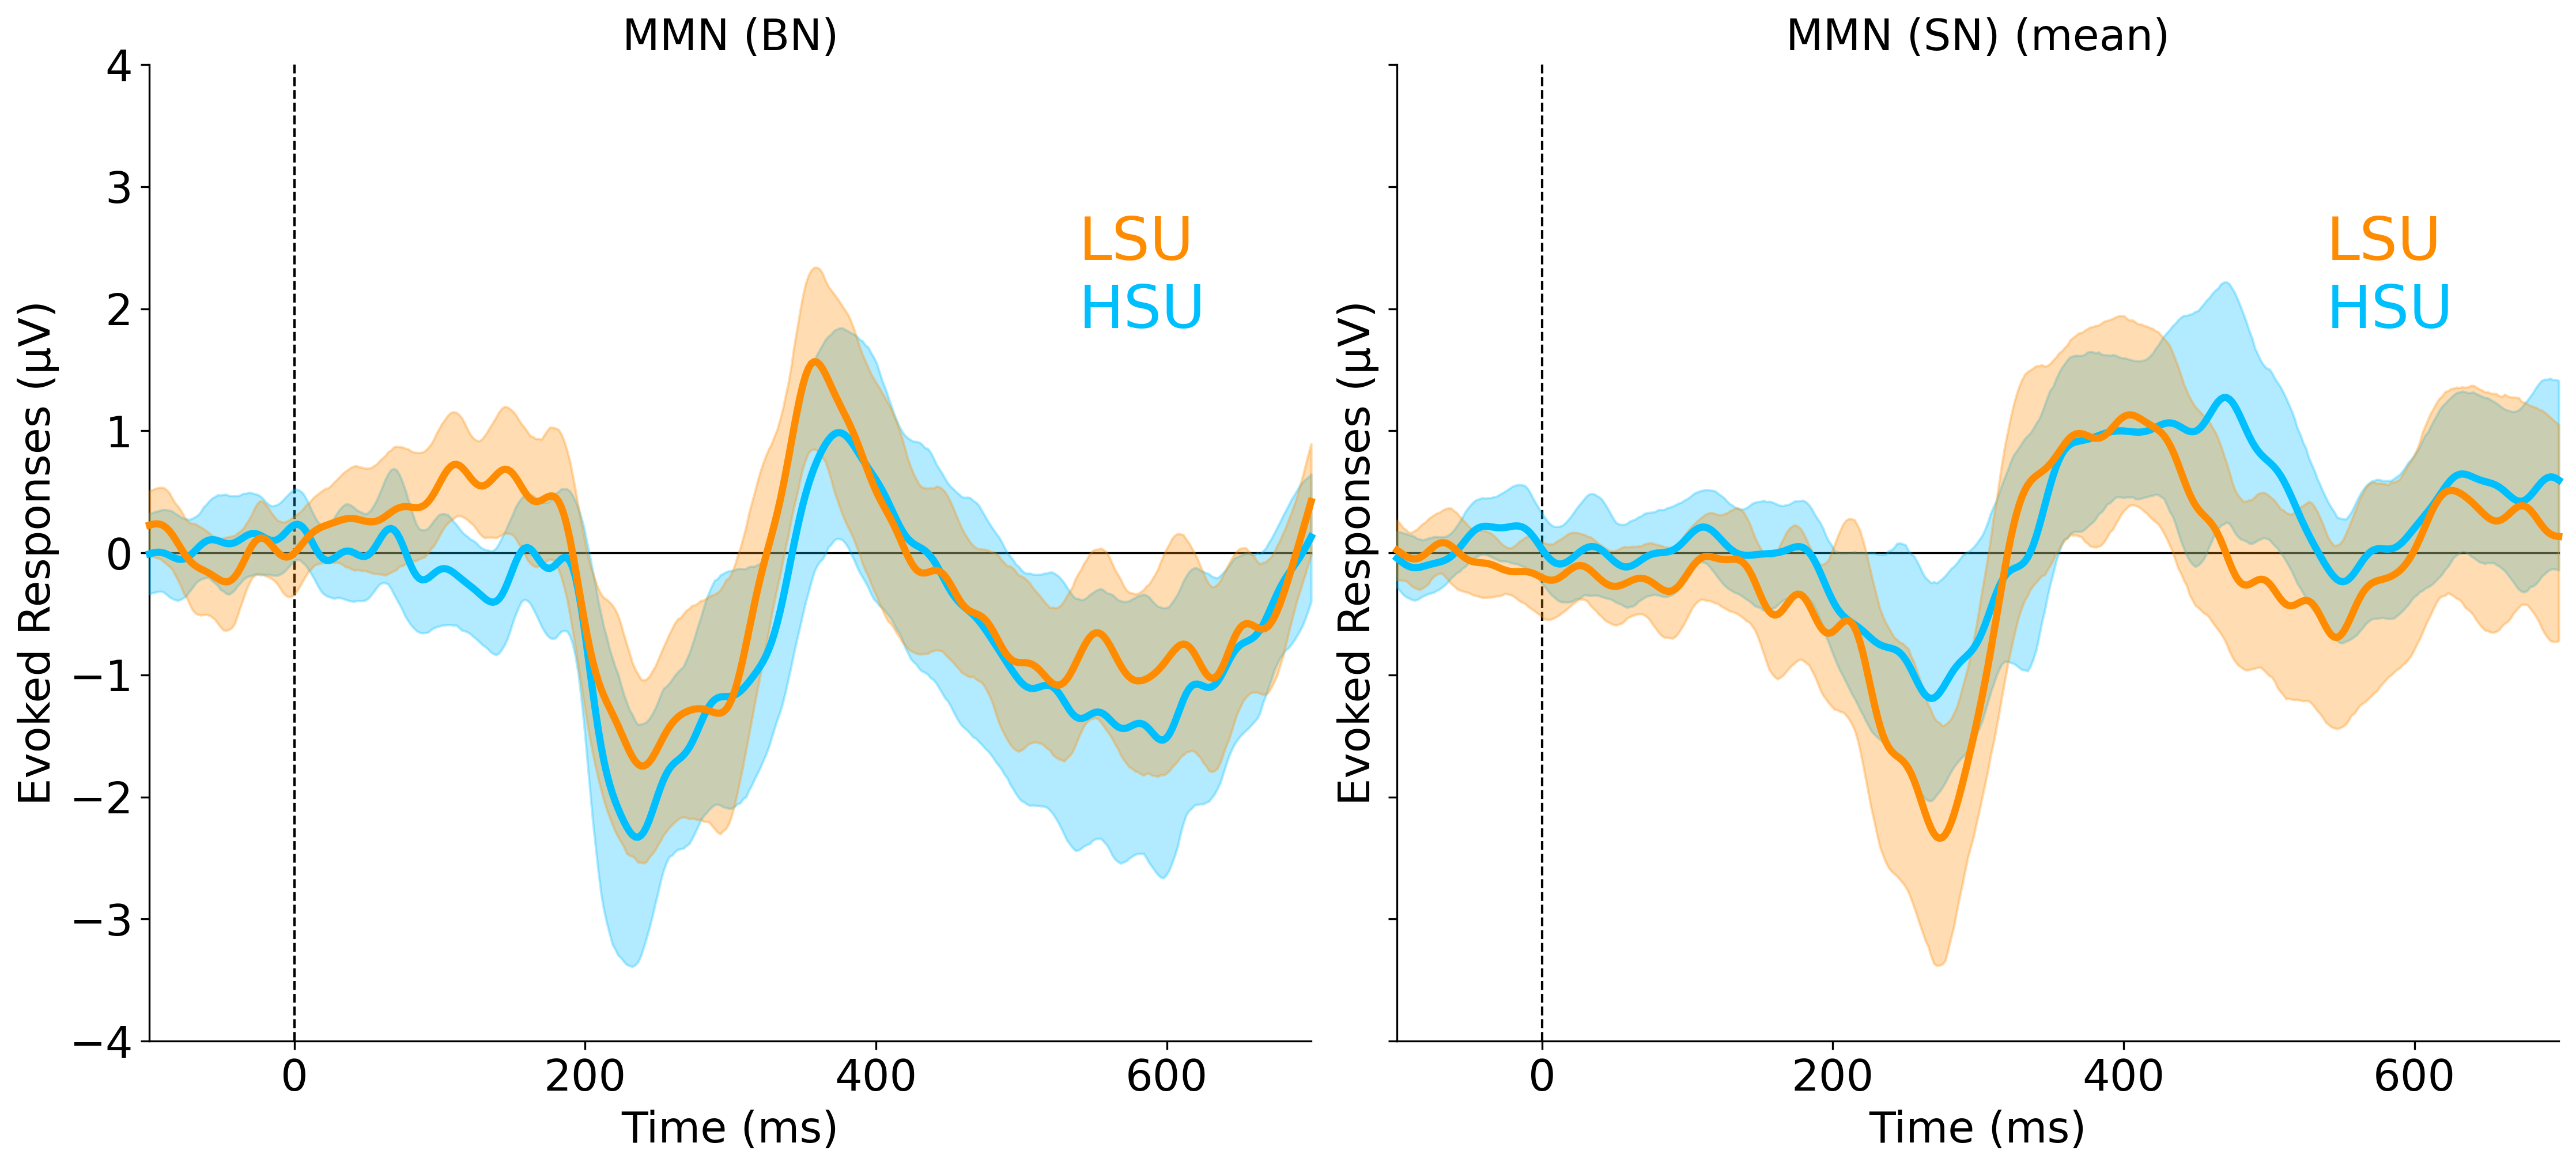

<Figure size 640x480 with 0 Axes>

In [71]:
# ### Personalized siginificant ERP for all the categories
evokeds = {'HSU': Personal_MMN_evokeds_list_high,
           'LSU': Personal_MMN_evokeds_list_low,
           }

# Subset the evoked data by selecting the time range
evokeds_subset = {}
for cond in evokeds:
    evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
    evokeds_subset[cond]  =evoked_crop 

# Plot the evoked responses
fig,axs = plt.subplots(1, 2, figsize=(15, 7),  sharey=True, gridspec_kw={'width_ratios': [1, 1]},dpi =300)

stylesdict ={'HSU': {"linewidth": 3,"linestyle":'solid'},
             'LSU' : {"linewidth": 3,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=['Cz','FCz','CPz','C2','C1','Fz',"Pz"],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes=axs[1],ylim = dict(eeg=[-4,4]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title='MMN (SN)')



# ### Non Personalized siginificant ERP for all the categories
evokeds = {'HSU': non_sign_MMN_evokeds_list_high,
           'LSU': non_sign_MMN_evokeds_list_low,
           }
# Subset the evoked data by selecting the time range
evokeds_subset = {}
for cond in evokeds:
    evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
    evokeds_subset[cond]  =evoked_crop 


mne.viz.plot_compare_evokeds(evokeds_subset, picks=['Cz'],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes=axs[0],ylim = dict(eeg=[-4,4]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title='MMN (BN)')


# Add an overall title for the whole plot
#fig.suptitle('Low, Medium and High smartphone user  ', fontsize=30)
axs[0].text(0.80,  0.73,f"HSU", transform=axs[0].transAxes, fontsize=25, color='deepskyblue')
axs[0].text( 0.80,0.80, f"LSU", transform=axs[0].transAxes, fontsize=25, color='darkorange')

axs[1].text(0.80,0.73, f"HSU", transform=axs[1].transAxes, fontsize=25, color='deepskyblue')
axs[1].text( 0.80,0.80, f"LSU", transform=axs[1].transAxes, fontsize=25, color='darkorange')
# Add an overall title for the whole plot

# Add an arrow pointing to a specific point
"""axs[0].text(0.50, 0.05, f"N1", transform=axs[0].transAxes, fontsize=24, color='black')
axs[0].text( 0.62,0.8, f"P1", transform=axs[0].transAxes, fontsize=24, color='black')
# Add an arrow pointing to a specific point
axs[1].text(0.45, 0.05, f"N1", transform=axs[1].transAxes, fontsize=24, color='black')

axs[1].text( 0.58,0.60, f"P1", transform=axs[1].transAxes, fontsize=24, color='black')

axs[1].text( 0.75,0.68, f"P2", transform=axs[1].transAxes, fontsize=24, color='black')"""
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.tight_layout(rect=[0, 0, 1, 0.98])
axes = fig.axes  # List of subplot axes
axes[0].set_ylabel('Evoked Responses (µV)')
axes[1].set_ylabel('Evoked Responses (µV)')
"""for ax in axes[1:]:  # Skip the first subplot (index 0)
    ax.set_ylabel('')"""
plt.rcParams.update({
    'xtick.labelsize': 25,  # X-axis tick labels font size
    'ytick.labelsize': 25,  # Y-axis tick labels font size
    'axes.labelsize': 25,   # Axis label font size
    'axes.titlesize': 25,   # Title font size 
    'legend.fontsize': 25,   # Legend font size
})
plt.show()
plt.gcf().patch.set_alpha(0) 
plt.show()

fig.savefig("name.png", transparent=True)

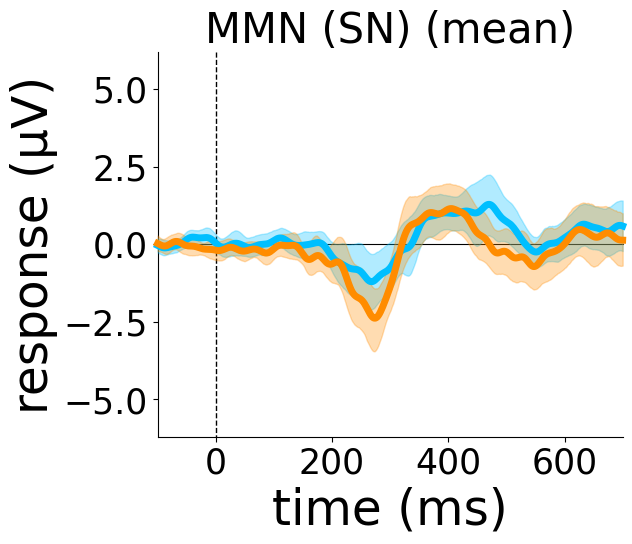

In [73]:
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {'HSU': Personal_MMN_evokeds_list_high,
           'LSU': Personal_MMN_evokeds_list_low,
           }
# Subset the evoked data by selecting the time range
evokeds_subset = {}
for cond in evokeds:
    evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
    evokeds_subset[cond]  =evoked_crop 


stylesdict ={"HSU": {"linewidth": 5,"linestyle":'solid'},
             'LSU' : {"linewidth": 5,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=['Cz','FCz','CPz','CP1','CP2','C2','C1','Fz',"Pz","FC1","FC2",],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='MMN (SN)')
# axs.text( 0.63,0.85, f"Beep MMN", transform=axs.transAxes, fontsize=25, color='Purple')
# axs.text( 0.72,0.72, f"SN MMN", transform=axs.transAxes, fontsize=25, color='green')
axs.set_ylabel('response (µV)')
axs.set_xlabel('time (ms)')
plt.rcParams.update({
    'xtick.labelsize': 25,  # X-axis tick labels font size
    'ytick.labelsize': 25,  # Y-axis tick labels font size
    'axes.labelsize': 35,   # Axis label font size
    'axes.titlesize': 30,   # Title font size 
    'legend.fontsize': 25,   # Legend font size
})
# Plot the evoked responses
plt.gcf().patch.set_alpha(0) 
plt.show()

fig.savefig("name.png", transparent=True)

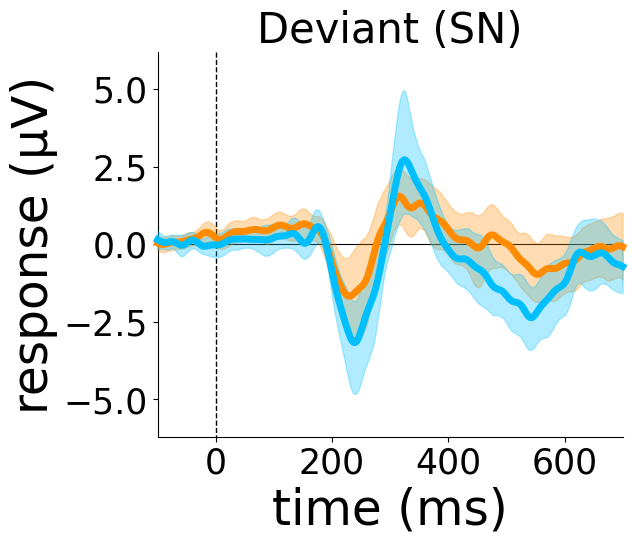

In [74]:
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {'HSU': B1_devi_eps_evoked_list_high,
           'LSU': B1_devi_eps_evoked_list_low,
           }
# Subset the evoked data by selecting the time range
evokeds_subset = {}
for cond in evokeds:
    evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
    evokeds_subset[cond]  =evoked_crop 


stylesdict ={"HSU": {"linewidth": 5,"linestyle":'solid'},
             'LSU' : {"linewidth": 5,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['darkorange','deepskyblue'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='Deviant (SN)')
# axs.text( 0.63,0.85, f"Beep MMN", transform=axs.transAxes, fontsize=25, color='Purple')
# axs.text( 0.72,0.72, f"SN MMN", transform=axs.transAxes, fontsize=25, color='green')
axs.set_ylabel('response (µV)')
axs.set_xlabel('time (ms)')
plt.rcParams.update({
    'xtick.labelsize': 25,  # X-axis tick labels font size
    'ytick.labelsize': 25,  # Y-axis tick labels font size
    'axes.labelsize': 35,   # Axis label font size
    'axes.titlesize': 30,   # Title font size 
    'legend.fontsize': 25,   # Legend font size
})
# Plot the evoked responses
plt.gcf().patch.set_alpha(0) 
plt.show()

fig.savefig("name.png", transparent=True)

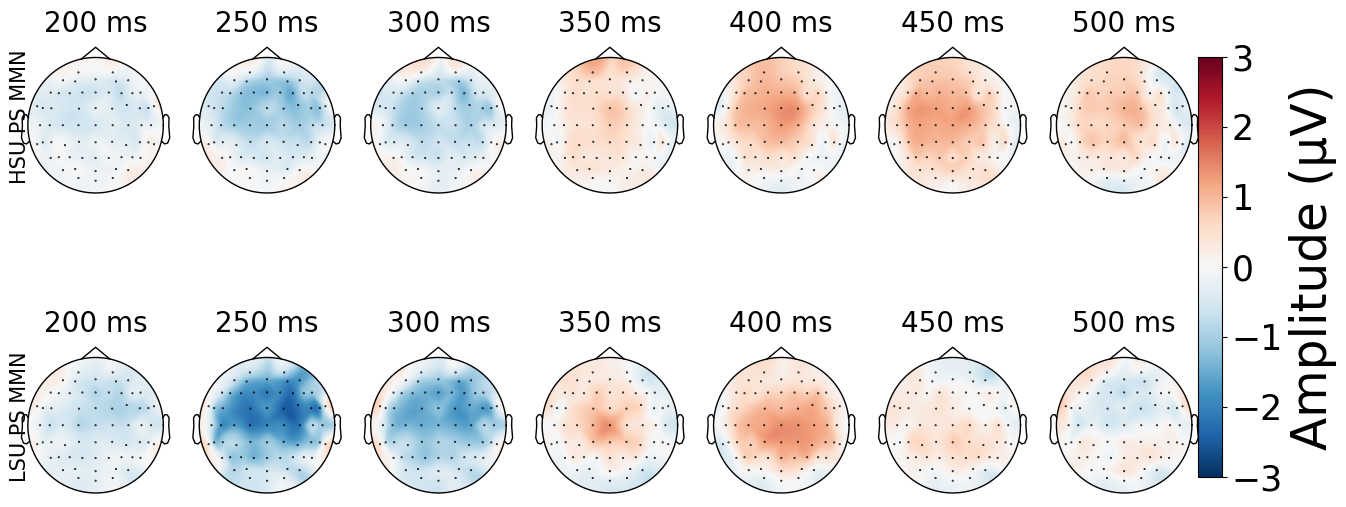

In [75]:
# TOPO MAP with all electrodes 

# TOPO MAP with all electrodes 
import matplotlib.pyplot as plt
import matplotlib as mpl
# Define time points
time_points = [.200, .250,.300,.350,.400, .45,.5,]

# Set the color scale range
vlim = (-3, 3)  # Adjust based on your data

# Create a grid of subplots
fig, axes = plt.subplots(2, len(time_points), figsize=(12, 6), constrained_layout=True)

# To store the last 'im' object for the colorbar
im = None

# Plot topomaps for the first evoked (Personal_MMN_erp)
for i, time in enumerate(time_points):
    mne.grand_average(Personal_MMN_evokeds_list_high).copy().drop_channels([ "FC3"]).plot_topomap(
        times=[time], axes=axes[0, i], colorbar=False, vlim=vlim, show=False,contours = 0,
    )
    axes[0, i].set_title(f"{time * 1000:.0f} ms",fontsize=20)

# Plot topomaps for the second evoked (B1_MMN_erp)
for i, time in enumerate(time_points):
    im= mne.grand_average(Personal_MMN_evokeds_list_low).copy().drop_channels(["FC3"]).plot_topomap(
        times=[time], axes=axes[1, i], colorbar=False, vlim=vlim, show=False,contours = 0,
    ) 
    axes[1, i].set_title(f"{time * 1000:.0f} ms",fontsize=20)

# Generate a shared colorbar
cbar_ax = fig.add_axes([0.99, 0.15, 0.02, 0.7])  # Position for the colorbar
norm = mpl.colors.Normalize(vmin=vlim[0], vmax=vlim[1])  # Normalize color scale
cmap = mpl.colormaps['RdBu_r']  # Choose a colormap (like 'RdBu_r')

# Add the colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, orientation='vertical', label='Amplitude (µV)')

# Add row labels
fig.text(0.0001, 0.75, 'HSU PS MMN', fontsize=15, rotation=90, va='center')
fig.text(0.0001, 0.25, 'LSU PS MMN', fontsize=15   , rotation=90, va='center')

plt.show()

# statistics analysis

In [47]:
import mne
# a couple of specific functions we'll use
from mne.channels import find_ch_adjacency, make_1020_channel_selections
mne.set_log_level('error')  # reduce extraneous MNE output
import matplotlib.pyplot as plt
import numpy as np
import glob

In [48]:
 


 
diff_waves = [mne.combine_evoked([Personal_MMN_evokeds_dict[subj], 
                                non_sign_MMN_evokeds_dict[subj]
                                ],
                                weights=[1, -1]
                                ) 
            for subj in Personal_MMN_evokeds_dict 
            ]

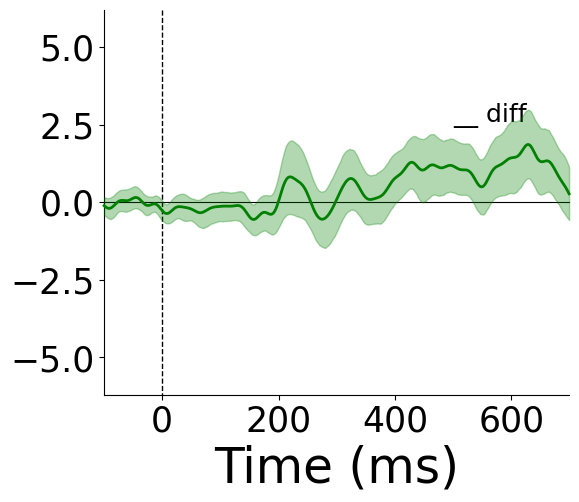

In [49]:

fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
           'diff_waves': diff_waves,

                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}
for cond in evokeds:
    evoked_crop  = [evk.copy().crop(tmin=-0.1, tmax=0.7) for evk in evokeds[cond]]
    evokeds_subset[cond]  =evoked_crop 


stylesdict ={
             'diff_waves' : {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')

axs.text( 0.75,0.71, f"__ diff", transform=axs.transAxes, fontsize=18)
axs.set_ylabel('')
plt.rcParams.update({
    'xtick.labelsize': 18,  # X-axis tick labels font size
    'ytick.labelsize': 18,  # Y-axis tick labels font size
    'axes.labelsize': 18,   # Axis label font size
    'axes.titlesize': 18,   # Title font size 
    'legend.fontsize': 18,   # Legend font size
})
plt.show( )# export it 

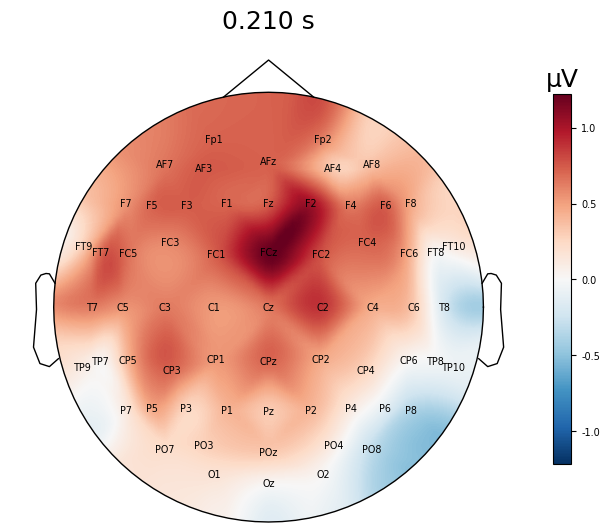

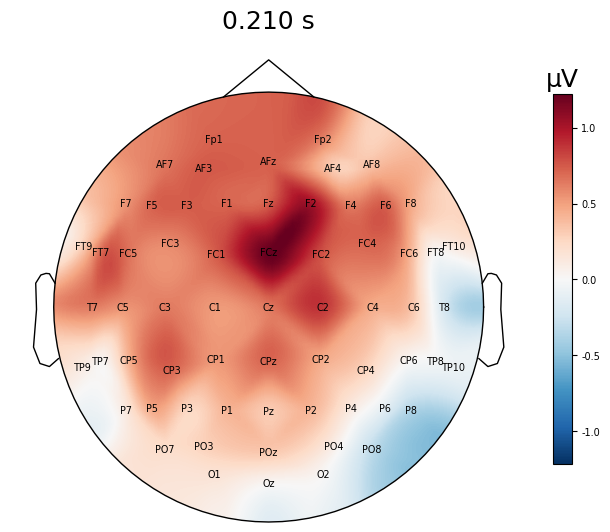

In [50]:
mne.viz.plot_evoked_topomap(mne.grand_average(diff_waves), 
                            times=.21000,
                            show_names=True, sensors=False,
                            contours=False,
                            size=4
                           )

In [51]:
time_win = (.200, .400)
roi = ('Cz', 'CPz', 'Pz')

y = np.array([np.mean(e.get_data(picks=roi, 
                                 tmin=time_win[0], 
                                 tmax=time_win[1]
                                 ),
                      axis=1) 
              for e in diff_waves
              ]
             )

# check shape of result
y.shape

(53, 3)

In [52]:
from scipy import stats 

t, pval = stats.ttest_1samp(y, 0)
print('Difference t = ', str(round(t[0], 2)), 'p = ', str(round(pval[0], 4)))

Difference t =  0.79 p =  0.4319


In [53]:
[v.get_data() for k,v in Personal_MMN_evokeds_dict.items()]

[array([[-1.36397626e-06, -1.16937904e-06, -9.29420708e-07, ...,
          4.10397616e-06,  3.96095943e-06,  3.86089061e-06],
        [-1.02300993e-07, -2.02723115e-07, -2.35928050e-07, ...,
         -3.08606956e-06, -3.00763735e-06, -2.89674045e-06],
        [ 1.79295386e-08,  7.59588816e-09,  2.54473291e-08, ...,
         -8.95577614e-07, -8.39166037e-07, -7.79373856e-07],
        ...,
        [-8.85085579e-07, -8.38049767e-07, -7.56188715e-07, ...,
         -7.23211128e-07, -8.07635249e-07, -8.51676051e-07],
        [ 1.20642454e-06,  1.45658135e-06,  1.69825735e-06, ...,
         -1.32511160e-06, -1.40232396e-06, -1.40073948e-06],
        [ 8.83069347e-07,  8.63520616e-07,  8.14464136e-07, ...,
          6.66480465e-07,  7.04276242e-07,  6.71206714e-07]]),
 array([[ 1.50193779e-07,  1.93288254e-07,  2.05525232e-07, ...,
         -2.93374103e-07, -3.05377822e-07, -3.06700047e-07],
        [-3.34670780e-09, -3.60676497e-08, -8.41765304e-08, ...,
         -1.04791116e-07, -1.68024490e

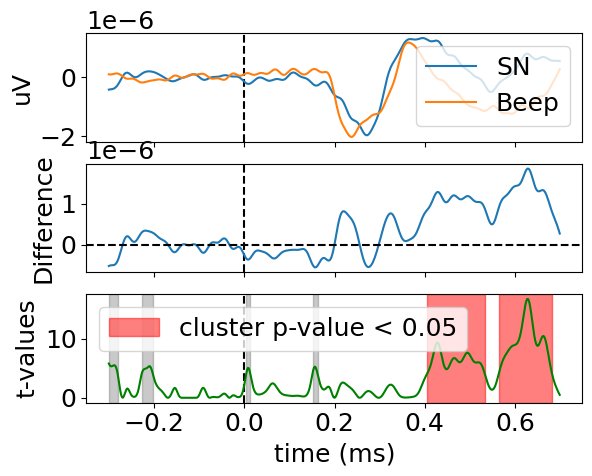

In [ ]:
# Transform each condition to array
condition1 = np.array([v.get_data(picks = ['Cz']) for k,v in Personal_MMN_evokeds_dict.items()])[:, 0, :]
condition2 = np.array([v.get_data(picks = ['Cz']) for k,v in non_sign_MMN_evokeds_dict.items()])[:, 0, :]

# Permutation test to find significant cluster of differences
t_vals, clusters, p_vals, h0 = mne.stats.permutation_cluster_test([condition1, condition2], out_type='mask', seed=111)

# Visualize
## <string>:1: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, ncols=1, sharex=True)

times = epochs.times
ax0.axvline(x=0, linestyle="--", color="black")
## <matplotlib.lines.Line2D object at 0x00000000BFAE7640>
ax0.plot(times, np.mean(condition1, axis=0), label="SN")
## [<matplotlib.lines.Line2D object at 0x00000000BFAF3D30>]
ax0.plot(times, np.mean(condition2, axis=0), label="Beep")
## [<matplotlib.lines.Line2D object at 0x00000000BFAF3F40>]
ax0.legend(loc="upper right")
## <matplotlib.legend.Legend object at 0x00000000BFAF3EE0>
ax0.set_ylabel("uV")

# Difference
ax1.axvline(x=0, linestyle="--", color="black")
ax1.plot(times, condition1.mean(axis=0) - condition2.mean(axis=0))
## [<matplotlib.lines.Line2D object at 0x00000000BFB07B20>]
ax1.axhline(y=0, linestyle="--", color="black")
## <matplotlib.lines.Line2D object at 0x00000000BFB07CD0>
ax1.set_ylabel("Difference")

# T-values
ax2.axvline(x=0, linestyle="--", color="black")
h = None
for i, c in enumerate(clusters):
    c = c[0]
    if p_vals[i] <= 0.05:
        h = ax2.axvspan(times[c.start],
                        times[c.stop - 1],
                        color='red',
                        alpha=0.5)
    else:
        ax2.axvspan(times[c.start],
                    times[c.stop - 1],
                    color=(0.3, 0.3, 0.3),
                    alpha=0.3)
## <matplotlib.patches.Polygon object at 0x00000000BFB16550>
## <matplotlib.patches.Polygon object at 0x00000000BFB16BE0>
hf = ax2.plot(times, t_vals, 'g')
if h is not None:
    plt.legend((h, ), ('cluster p-value < 0.05', ))
## <matplotlib.legend.Legend object at 0x00000000BFB16D00>
plt.xlabel("time (ms)")
## Text(0.5, 0, 'time (ms)')
plt.ylabel("t-values") 
## Text(0, 0.5, 't-values')
#plt.savefig("figures/fig2.png")

plt.show()

### Mean Amplitude analysis

In [78]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Assuming your dictionaries are structured as:
# case1_dict = {'subject1': evoked_obj1, 'subject2': evoked_obj2, ...}
# case2_dict = {'subject1': evoked_obj1, 'subject2': evoked_obj2, ...}

def extract_mmn_amplitudes(case1_dict, case2_dict, time_window=(100, 250), channels=None):
    """Extract mean MMN amplitudes within the specified time window for each subject."""
    # Ensure both dictionaries have the same subjects
    common_subjects = sorted(set(case1_dict.keys()) & set(case2_dict.keys()))
    
    amplitudes_case1 = []
    amplitudes_case2 = []
    
    for subject in common_subjects:
        # Extract MMN data for the time window
        case1_data = case1_dict[subject].copy().crop(tmin=time_window[0]/1000, 
                                                     tmax=time_window[1]/1000)
        case2_data = case2_dict[subject].copy().crop(tmin=time_window[0]/1000, 
                                                     tmax=time_window[1]/1000)
        
        # Get mean amplitude for specific channels or all channels
        if channels:
            case1_amp = np.mean(case1_data.get_data(picks=channels), axis=1)
            case2_amp = np.mean(case2_data.get_data(picks=channels), axis=1)
        else:
            case1_amp = np.mean(case1_data.get_data(), axis=1)
            case2_amp = np.mean(case2_data.get_data(), axis=1)
        
        amplitudes_case1.append(case1_amp)
        amplitudes_case2.append(case2_amp)
    
    return np.array(amplitudes_case1), np.array(amplitudes_case2), common_subjects
def run_statistical_tests(case1_amps, case2_amps):
    """Perform statistical tests on MMN amplitudes."""
    results = {}
    
    # If multiple channels, average across channels for overall test
    if case1_amps.shape[1] > 1:
        mean_case1 = np.mean(case1_amps, axis=1)
        mean_case2 = np.mean(case2_amps, axis=1)
        t_stat, p_value = stats.ttest_rel(mean_case1, mean_case2)
        results['overall'] = {'t_stat': t_stat, 'p_value': p_value}
    
    # Test each channel separately
    for i in range(case1_amps.shape[1]):
        t_stat, p_value = stats.ttest_rel(case1_amps[:, i], case2_amps[:, i])
        results[f'channel_{i}'] = {'t_stat': t_stat, 'p_value': p_value}
    
    return results
def visualize_results(case1_amps, case2_amps, subjects, channel_names=None):
    """Create visualizations to compare MMN amplitudes between cases."""
    # Calculate mean and standard error across subjects
    mean_case1 = np.mean(case1_amps, axis=0)
    mean_case2 = np.mean(case2_amps, axis=0)
    se_case1 = np.std(case1_amps, axis=0) / np.sqrt(len(subjects))
    se_case2 = np.std(case2_amps, axis=0) / np.sqrt(len(subjects))
    
    # Bar plot for each channel
    n_channels = case1_amps.shape[1]
    x = np.arange(n_channels)
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(x - width/2, mean_case1, width, yerr=se_case1, label='Case 1')
    bars2 = ax.bar(x + width/2, mean_case2, width, yerr=se_case2, label='Case 2')
    
    ax.set_ylabel('Mean Amplitude (µV)')
    ax.set_title('MMN Amplitude Comparison Between Cases')
    if channel_names:
        ax.set_xticks(x)
        ax.set_xticklabels(channel_names)
    else:
        ax.set_xlabel('Channel Index')
    
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)
    
    return fig


Statistical test results:
overall: t=2.728, p=0.009
channel_0: t=2.117, p=0.039
channel_1: t=3.191, p=0.002
channel_2: t=2.577, p=0.013


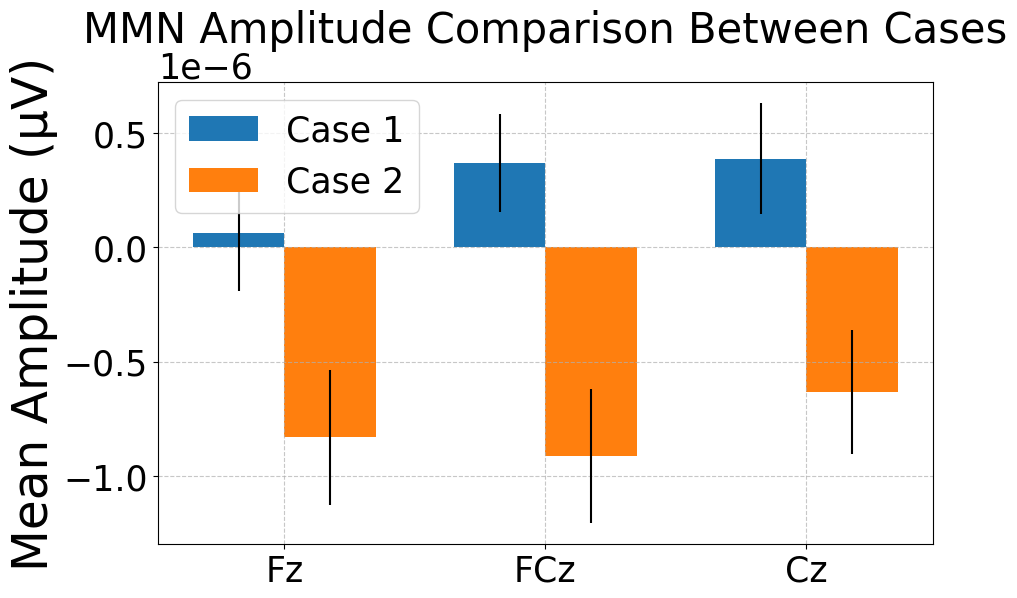

In [86]:
# Define parameters
time_window = (400, 580)  # MMN typically 100-250ms
channels = ['Fz', 'FCz', 'Cz']  # Common MMN channels

# Extract amplitudes
case1_amps, case2_amps, subjects = extract_mmn_amplitudes(
    Personal_MMN_evokeds_dict ,non_sign_MMN_evokeds_dict , time_window=time_window, channels=channels
)

# Run statistical tests
results = run_statistical_tests(case1_amps, case2_amps)
print("Statistical test results:")
for key, data in results.items():
    print(f"{key}: t={data['t_stat']:.3f}, p={data['p_value']:.3f}")

# Visualize
fig = visualize_results(case1_amps, case2_amps, subjects, channel_names=channels)
plt.show()


### Latency analysis

In [167]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

def extract_mmn_latencies(case1_dict, case2_dict, time_window=(100, 300), channels=None, 
                          method='peak', fractional_area=0.50):
    """Extract MMN latencies using specified method."""
    common_subjects = sorted(set(case1_dict.keys()) & set(case2_dict.keys()))
    time_axis = None  # Will be determined from the first subject's data
    
    latencies_case1 = []
    latencies_case2 = []
    
    for subject in common_subjects:
        # Get the MMN evoked data for selected channels
        if channels:
            case1_data = case1_dict[subject].copy().pick_channels(channels)
            case2_data = case2_dict[subject].copy().pick_channels(channels)
        else:
            case1_data = case1_dict[subject].copy()
            case2_data = case2_dict[subject].copy()
        
        # Extract the time axis if not yet done
        if time_axis is None:
            time_axis = case1_data.times
            
        # Crop to time window of interest
        case1_data = case1_data.copy().crop(tmin=time_window[0]/1000, tmax=time_window[1]/1000)
        case2_data = case2_dict[subject].copy().crop(tmin=time_window[0]/1000, tmax=time_window[1]/1000)
        
        # Get the data as numpy arrays - average across selected channels
        case1_avg = np.mean(case1_data.data, axis=0) if len(case1_data.data.shape) > 1 else case1_data.data
        case2_avg = np.mean(case2_data.data, axis=0) if len(case2_data.data.shape) > 1 else case2_data.data
        
        # Get the time axis for this window
        window_times = case1_data.times
        
        # Extract latency based on the selected method
        if method == 'peak':
            # Find the peak latency (time of max negative amplitude)
            peak_idx1 = np.argmin(case1_avg)
            peak_idx2 = np.argmin(case2_avg)
            lat1 = window_times[peak_idx1] * 1000  # Convert to ms
            lat2 = window_times[peak_idx2] * 1000
            
        elif method == 'fractional_area':
            # Fractional area latency (more robust against noise)
            lat1 = get_fractional_area_latency(case1_avg, window_times, fractional_area) * 1000
            lat2 = get_fractional_area_latency(case2_avg, window_times, fractional_area) * 1000
            
        elif method == 'onset':
            # Onset latency (when amplitude reaches a percentage of peak)
            percent_threshold = 0.50  # Typically 50% of peak amplitude
            lat1 = get_onset_latency(case1_avg, window_times, percent_threshold) * 1000
            lat2 = get_onset_latency(case2_avg, window_times, percent_threshold) * 1000
            
        latencies_case1.append(lat1)
        latencies_case2.append(lat2)
    
    return np.array(latencies_case1), np.array(latencies_case2), common_subjects

def get_fractional_area_latency(waveform, times, fraction=0.50):
    """Determine the latency at which a fraction of the area under the curve is reached."""
    # For MMN, we're interested in the negative area
    neg_waveform = np.minimum(waveform, 0)  # Keep only negative values, set positive to 0
    
    # Calculate cumulative area
    area = np.trapz(neg_waveform, times)
    if area >= 0:  # If no negative area (no clear MMN)
        return np.nan
        
    cumulative_area = np.zeros_like(times)
    for i in range(1, len(times)):
        cumulative_area[i] = np.trapz(neg_waveform[:i+1], times[:i+1])
    
    # Find the timepoint where the cumulative area reaches the target fraction
    threshold = fraction * area
    crossing_idx = np.argmin(np.abs(cumulative_area - threshold))
    
    return times[crossing_idx]

def get_onset_latency(waveform, times, percent_threshold=0.50):
    """Determine the onset latency when signal reaches percent_threshold of peak amplitude."""
    peak_idx = np.argmin(waveform)
    peak_amplitude = waveform[peak_idx]
    
    # Threshold is a percentage of peak amplitude
    threshold = peak_amplitude * percent_threshold
    
    # Find the first point where amplitude exceeds threshold
    for i in range(peak_idx):
        if waveform[i] <= threshold:  # For negative MMN, we use <= 
            return times[i]
    
    # If no crossing found, return NaN
    return np.nan
def run_latency_statistical_tests(case1_latencies, case2_latencies):
    """Perform statistical tests on MMN latencies."""
    # Remove any NaN values where latency couldn't be determined
    valid_indices = ~np.isnan(case1_latencies) & ~np.isnan(case2_latencies)
    valid_lat1 = case1_latencies[valid_indices]
    valid_lat2 = case2_latencies[valid_indices]
    
    # Calculate summary statistics
    mean_lat1 = np.mean(valid_lat1)
    mean_lat2 = np.mean(valid_lat2)
    std_lat1 = np.std(valid_lat1)
    std_lat2 = np.std(valid_lat2)
    
    # Paired t-test for latency differences
    t_stat, p_value = stats.ttest_rel(valid_lat1, valid_lat2)
    
    result = {
        'mean_latency_case1': mean_lat1,
        'mean_latency_case2': mean_lat2, 
        'std_latency_case1': std_lat1,
        'std_latency_case2': std_lat2,
        't_stat': t_stat,
        'p_value': p_value,
        'n_valid': len(valid_lat1)
    }
    
    return result
def visualize_latency_results(case1_latencies, case2_latencies, subjects, method_name):
    """Create visualizations to compare MMN latencies between cases."""
    valid_indices = ~np.isnan(case1_latencies) & ~np.isnan(case2_latencies)
    valid_lat1 = case1_latencies[valid_indices]
    valid_lat2 = case2_latencies[valid_indices]
    valid_subjects = [subjects[i] for i in range(len(subjects)) if valid_indices[i]]
    
    # Calculate mean and standard error
    mean_lat1 = np.mean(valid_lat1)
    mean_lat2 = np.mean(valid_lat2)
    se_lat1 = np.std(valid_lat1) / np.sqrt(len(valid_lat1))
    se_lat2 = np.std(valid_lat2) / np.sqrt(len(valid_lat2))
    
    # Create bar plot for latencies
    fig, ax = plt.subplots(figsize=(8, 5))
    x = [1, 2]
    means = [mean_lat1, mean_lat2]
    errors = [se_lat1, se_lat2]
    
    bars = ax.bar(x, means, width=0.6, yerr=errors, capsize=10,
                 color=['blue', 'orange'], alpha=0.7)
    
    ax.set_ylabel('Latency (ms)')
    ax.set_title(f'MMN {method_name} Latency Comparison Between Cases')
    ax.set_xticks(x)
    ax.set_xticklabels(['Case 1', 'Case 2'])
    ax.grid(True, linestyle='--', alpha=0.7, axis='y')
    
    for i, (lat1, lat2) in enumerate(zip(valid_lat1, valid_lat2)):
        plt.plot([1, 2], [lat1, lat2], 'k-', alpha=0.2)
    
    # Add individual data points
    ax.scatter([1] * len(valid_lat1), valid_lat1, color='blue', alpha=0.6)
    ax.scatter([2] * len(valid_lat2), valid_lat2, color='orange', alpha=0.6)
    
    return fig


Peak Latency Results:
Case 1: 252.7 ± 44.7 ms
Case 2: 264.6 ± 36.2 ms
t(52) = -1.607, p = 0.114


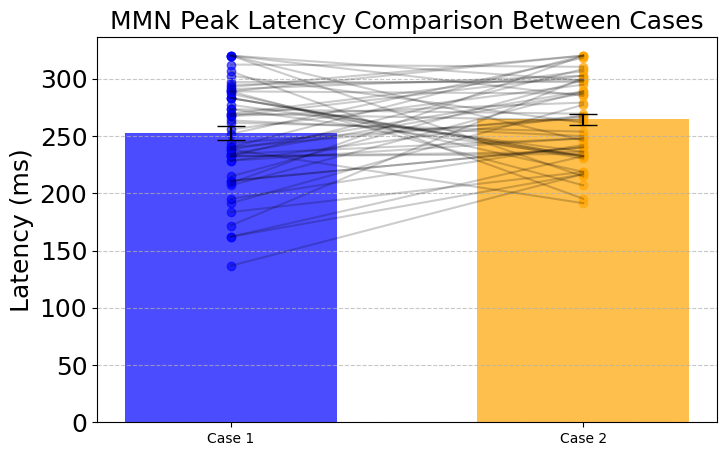


Fractional Area Latency Results:
Case 1: 219.1 ± 33.0 ms
Case 2: 232.2 ± 31.5 ms
t(49) = -2.021, p = 0.049


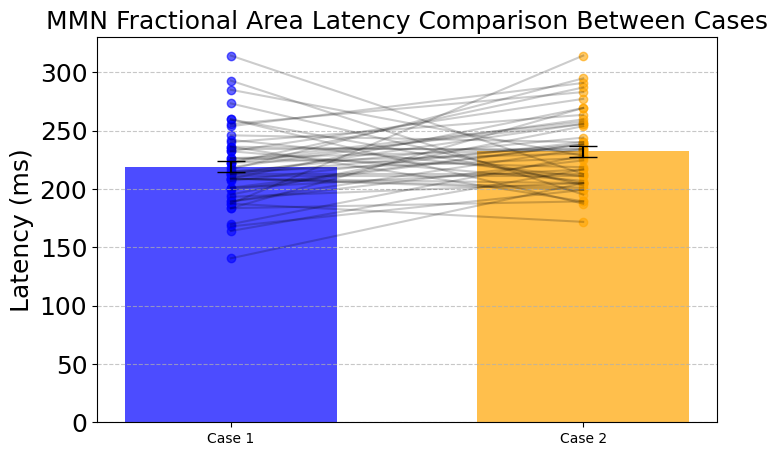

In [ ]:
# Define parameters based on MMN literature
time_window = (135, 320)  # ms - typical MMN window
channels = ['Cz']  # Typical frontocentral electrodes for MMN

# 1. Peak latency analysis
peak_lat1, peak_lat2, subjects = extract_mmn_latencies(
    Personal_MMN_evokeds_dict ,non_sign_MMN_evokeds_dict , time_window=time_window, 
    channels=channels, method='peak')

peak_results = run_latency_statistical_tests(peak_lat1, peak_lat2)
print("Peak Latency Results:") 
print(f"Case 1: {peak_results['mean_latency_case1']:.1f} ± {peak_results['std_latency_case1']:.1f} ms")
print(f"Case 2: {peak_results['mean_latency_case2']:.1f} ± {peak_results['std_latency_case2']:.1f} ms")
print(f"t({peak_results['n_valid']-1}) = {peak_results['t_stat']:.3f}, p = {peak_results['p_value']:.3f}")

# Visualize
peak_fig = visualize_latency_results(peak_lat1, peak_lat2, subjects, "Peak")
plt.show()

# 2. Fractional area latency analysis (50%) - more robust to noise
area_lat1, area_lat2, subjects = extract_mmn_latencies(
    Personal_MMN_evokeds_dict ,non_sign_MMN_evokeds_dict , time_window=time_window, 
    channels=channels, method='fractional_area', fractional_area=0.25)

area_results = run_latency_statistical_tests(area_lat1, area_lat2)
print("\nFractional Area Latency Results:")
print(f"Case 1: {area_results['mean_latency_case1']:.1f} ± {area_results['std_latency_case1']:.1f} ms")
print(f"Case 2: {area_results['mean_latency_case2']:.1f} ± {area_results['std_latency_case2']:.1f} ms")
print(f"t({area_results['n_valid']-1}) = {area_results['t_stat']:.3f}, p = {area_results['p_value']:.3f}")

# Visualize
area_fig = visualize_latency_results(area_lat1, area_lat2, subjects, "Fractional Area")
plt.show()
